<a href="https://colab.research.google.com/github/Oresco3uk/Oresco3uk/blob/main/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset and Project Overview**

# **Walmart Recruiting - Store Sales Forecasting**
The dataset contains historical sales data for 45 Walmart stores located in different regions. Each store contains a number of departments, and the goal is to predict the department-wide sales for each store.

In addition, Walmart runs several promotional markdown events throughout the year. These markdowns precede prominent holidays, the four largest of which are the Super Bowl, Labor Day, Thanksgiving, and Christmas. The weeks including these holidays are weighted five times higher in the evaluation than non-holiday weeks. Part of the challenge presented by this competition is modeling the effects of markdowns on these holiday weeks in the absence of complete/ideal historical data.
### **Data Files**
**stores.csv**

This file contains anonymized information about the 45 stores, indicating the type and size of store.

**train.csv**

This is the historical training data, which covers to 2010-02-05 to 2012-11-01. Within this file you will find the following fields:

`Store` - the store number <br>
`Dept` - the department number <br>
`Date` - the week <br>
`Weekly_Sales` -  sales for the given department in the given store <br>
`IsHoliday` - whether the week is a special holiday week <br>

**test.csv**

This file is identical to train.csv, except we have withheld the weekly sales. You must predict the sales for each triplet of store, department, and date in this file.

**features.csv**

This file contains additional data related to the store, department, and regional activity for the given dates. It contains the following fields:

`Store` - the store number <br>
`Date` - the week <br>
`Temperature` - average temperature in the region <br>
`Fuel_Price` - cost of fuel in the region <br>
`MarkDown1-5` - anonymized data related to promotional markdowns that Walmart is running. MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA. <br>
`CPI` - the consumer price index <br>
`Unemployment` - the unemployment rate <br>
`IsHoliday` - whether the week is a special holiday week <br>

For convenience, the four holidays fall within the following weeks in the dataset (not all holidays are in the data):
- Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
- Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
- Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
- Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

The task is to predict Weekly Sales for specific departments across 45 different Walmart stores. A key challenge is that Walmart holds major promotional events (Markdowns) before four major holidays: Super Bowl, Labor Day, Thanksgiving, and Christmas. These weeks have a significantly higher impact on total revenue and are weighted more heavily in the evaluation.

### Libraries and Data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
!pip install pmdarima
import pmdarima as pm
from pmdarima.arima import auto_arima

In [ ]:
features = pd.read_csv('/content/sample_data/features.csv')
stores = pd.read_csv('/content/sample_data/stores.csv')
test = pd.read_csv('/content/sample_data/test.csv')
train = pd.read_csv('/content/sample_data/train.csv')

### Data Check

In [ ]:
print('First 5 rows of Features Dataset:')
display(features.head())
print('\nFirst 5 rows of Stores Dataset:')
display(stores.head())
print('\nFirst 5 rows of Test Dataset:')
display(test.head())
print('\nFirst 5 rows of Train Dataset:')
display(train.head())

First 5 rows of Features Dataset:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



First 5 rows of Stores Dataset:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



First 5 rows of Test Dataset:


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False



First 5 rows of Train Dataset:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
print('Shape Features Dataset:')
display(features.shape)
print('Shape Stores Dataset:')
display(stores.shape)
print('Shape Test Dataset:')
display(test.shape)
print('Shape Train Dataset:')
display(train.shape)

Shape Features Dataset:


(8190, 12)

Shape Stores Dataset:


(45, 3)

Shape Test Dataset:


(115064, 4)

Shape Train Dataset:


(421570, 5)

In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


####
---
## Stage 1 *(The Master Merge)*
---
####

In [ ]:
# Identification of Train VS Test dataset
train['is_train'] = 1
test['is_train'] = 0

df = pd.concat([train, test], axis=0).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(1)
memory usage: 21.0+ MB


In [ ]:
df = pd.merge(df, stores, on='Store', how='left')

print(df.shape)
display(df.head())

(536634, 8)


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size
0,1,1,2010-02-05,24924.50,False,1,A,151315
1,1,1,2010-02-12,46039.49,True,1,A,151315
2,1,1,2010-02-19,41595.55,False,1,A,151315
3,1,1,2010-02-26,19403.54,False,1,A,151315
4,1,1,2010-03-05,21827.90,False,1,A,151315


In [ ]:
df = pd.merge(df, features, on=['Store', 'Date', 'IsHoliday'], how='left')

print(df.shape)
display(df.head())

(536634, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


####
---
### Stage 2 *(Handling Missing Values)*
---
####

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
 6   Type          536634 non-null  object 
 7   Size          536634 non-null  int64  
 8   Temperature   536634 non-null  float64
 9   Fuel_Price    536634 non-null  float64
 10  MarkDown1     265596 non-null  float64
 11  MarkDown2     197685 non-null  float64
 12  MarkDown3     242326 non-null  float64
 13  MarkDown4     237143 non-null  float64
 14  MarkDown5     266496 non-null  float64
 15  CPI           498472 non-null  float64
 16  Unemployment  498472 non-null  float64
dtypes: bool(1), float64(10), int64(4), object(2)
mem

**Missing values appears in all Markdown 1-5, let's fill them up with 0**

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
# Confirm there's no other missing values

df.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
is_train,0
Type,0
Size,0
Temperature,0
Fuel_Price,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  536634 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
 6   Type          536634 non-null  object 
 7   Size          536634 non-null  int64  
 8   Temperature   536634 non-null  float64
 9   Fuel_Price    536634 non-null  float64
 10  MarkDown1     536634 non-null  float64
 11  MarkDown2     536634 non-null  float64
 12  MarkDown3     536634 non-null  float64
 13  MarkDown4     536634 non-null  float64
 14  MarkDown5     536634 non-null  float64
 15  CPI           536634 non-null  float64
 16  Unemployment  536634 non-null  float64
dtypes: bool(1), float64(10), int64(4), object(2)
mem

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


####
---
### Stage 3 *(Feature Engineering)*
---
####

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         536634 non-null  int64         
 1   Dept          536634 non-null  int64         
 2   Date          536634 non-null  datetime64[ns]
 3   Weekly_Sales  536634 non-null  float64       
 4   IsHoliday     536634 non-null  bool          
 5   is_train      536634 non-null  int64         
 6   Type          536634 non-null  object        
 7   Size          536634 non-null  int64         
 8   Temperature   536634 non-null  float64       
 9   Fuel_Price    536634 non-null  float64       
 10  MarkDown1     536634 non-null  float64       
 11  MarkDown2     536634 non-null  float64       
 12  MarkDown3     536634 non-null  float64       
 13  MarkDown4     536634 non-null  float64       
 14  MarkDown5     536634 non-null  float64       
 15  CPI           536

**Temporal Features** <br> Extraction of `Month`, `Day`, `WeekOfYear`, and `Year` from the Date

In [ ]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,...,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010,5
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,...,0.0,0.0,0.0,0.0,211.242170,8.106,12,2,2010,6
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,...,0.0,0.0,0.0,0.0,211.289143,8.106,19,2,2010,7
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,...,0.0,0.0,0.0,0.0,211.319643,8.106,26,2,2010,8
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,...,0.0,0.0,0.0,0.0,211.350143,8.106,5,3,2010,9


**The "Days to Holiday" Feature** <br>
Since Black Friday and Christmas move, create a counter for *"Days until next major Holiday."*

Here, I used the 4 christmas dates mentioned above in the introduction and used them as major holidays. That's what I understood by the script given

In [ ]:
major_holiday = ['31-Dec-10', '30-Dec-11', '28-Dec-12', '27-Dec-13']
major_holiday = pd.to_datetime(major_holiday)

In [ ]:
major_holiday

DatetimeIndex(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'], dtype='datetime64[ns]', freq=None)

In [ ]:
holiday = pd.DataFrame({'next_holiday' :major_holiday})

df = df.sort_values('Date')
holiday

,next_holiday
0,2010-12-31
1,2011-12-30
2,2012-12-28
3,2013-12-27


In [ ]:
df.dropna(subset=['Date'], inplace=True)
df = pd.merge_asof(df, holiday, left_on='Date', right_on='next_holiday', direction='forward')

df.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday
489388,31,82,2013-04-05,0.00,False,0,A,203750,58.80,3.583,...,351.03,405.82,6611.59,224.719258,6.112,5,4,2013,14,2013-12-27
351479,3,2,2012-05-18,19237.79,False,1,B,37392,72.38,3.630,...,0.30,143.23,805.06,225.251202,6.664,18,5,2012,20,2012-12-28
90973,18,52,2010-09-10,3573.93,True,1,B,120653,67.09,2.717,...,0.00,0.00,0.00,132.756452,9.342,10,9,2010,36,2010-12-31
446475,44,38,2012-12-28,0.00,True,0,C,39910,30.07,3.147,...,6.69,48.36,265.43,131.747000,5.217,28,12,2012,52,2012-12-28
287143,23,3,2011-12-16,27936.62,False,1,B,114533,32.99,3.445,...,738.38,591.22,4241.95,136.533516,4.420,16,12,2011,50,2011-12-30
319281,25,4,2012-03-02,19883.74,False,1,B,128107,36.01,3.816,...,21.38,12085.01,1327.97,213.671813,6.961,2,3,2012,9,2012-12-28
177280,12,13,2011-04-01,49214.78,False,1,B,112238,63.63,3.772,...,0.00,0.00,0.00,128.719935,13.736,1,4,2011,13,2011-12-30
130373,4,91,2010-12-10,62282.52,False,1,A,205863,42.40,2.860,...,0.00,0.00,0.00,126.793400,7.127,10,12,2010,49,2010-12-31
301694,19,72,2012-01-20,69084.67,False,1,A,203819,23.44,3.705,...,225.06,1122.08,2863.93,136.856419,7.943,20,1,2012,3,2012-12-28
174946,33,83,2011-03-25,3181.61,False,1,A,39690,63.34,3.716,...,0.00,0.00,0.00,128.616064,8.951,25,3,2011,12,2011-12-30


In [ ]:
df['next_holiday'].unique()

<DatetimeArray>
['2010-12-31 00:00:00', '2011-12-30 00:00:00', '2012-12-28 00:00:00',
 '2013-12-27 00:00:00']
Length: 4, dtype: datetime64[ns]

In [ ]:
df['Days_To_Holiday'] = (df['next_holiday'] - df['Date']).dt.days

df.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday
320781,3,31,2012-03-02,976.38,False,1,B,37392,61.65,3.630,...,2666.22,1524.87,224.347025,6.833,2,3,2012,9,2012-12-28,301
86813,9,44,2010-08-27,2966.82,False,1,B,125833,84.01,2.619,...,0.00,0.00,215.119954,6.442,27,8,2010,34,2010-12-31,126
422872,33,95,2012-11-02,0.00,False,0,A,39690,70.96,4.099,...,0.00,561.20,131.236226,6.895,2,11,2012,44,2012-12-28,56
270940,26,11,2011-11-11,12887.99,False,1,A,152513,40.08,3.570,...,1581.44,2399.33,136.461806,7.598,11,11,2011,45,2011-12-30,49
150919,42,40,2011-01-28,21514.18,False,1,C,39690,53.03,3.231,...,0.00,0.00,127.580032,8.744,28,1,2011,4,2011-12-30,336
369615,17,16,2012-06-29,25881.68,False,1,B,93188,71.14,3.681,...,357.75,1195.05,130.756267,6.235,29,6,2012,26,2012-12-28,182
252398,6,26,2011-09-23,6919.28,False,1,A,202505,78.49,3.467,...,0.00,0.00,217.918847,6.925,23,9,2011,38,2011-12-30,98
99748,39,81,2010-10-01,17871.12,False,1,A,184109,72.74,2.603,...,0.00,0.00,210.440443,8.476,1,10,2010,39,2010-12-31,91
309918,16,55,2012-02-10,7469.40,True,1,B,57197,23.69,3.103,...,9481.58,6298.10,196.919506,6.162,10,2,2012,6,2012-12-28,322
491618,5,60,2013-04-12,0.00,False,0,B,34875,62.36,3.529,...,184.54,1703.57,225.766502,5.278,12,4,2013,15,2013-12-27,259


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            536634 non-null  int64         
 1   Dept             536634 non-null  int64         
 2   Date             536634 non-null  datetime64[ns]
 3   Weekly_Sales     536634 non-null  float64       
 4   IsHoliday        536634 non-null  bool          
 5   is_train         536634 non-null  int64         
 6   Type             536634 non-null  object        
 7   Size             536634 non-null  int64         
 8   Temperature      536634 non-null  float64       
 9   Fuel_Price       536634 non-null  float64       
 10  MarkDown1        536634 non-null  float64       
 11  MarkDown2        536634 non-null  float64       
 12  MarkDown3        536634 non-null  float64       
 13  MarkDown4        536634 non-null  float64       
 14  MarkDown5        536

**Lag Features** <br> Create a column for `Sales_Last_Year` by shifting sales data by 52 weeks. This is the strongest predictor for seasonal retail

In [ ]:
df['Sales_Last_Year'] = df['Weekly_Sales'].shift(52)

df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year
536629,4,25,2013-07-26,0.0,False,0,A,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536630,8,87,2013-07-26,0.0,False,0,A,155078,78.70,3.620,...,2343.11,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536631,25,46,2013-07-26,0.0,False,0,B,128107,68.72,3.804,...,1129.68,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536632,4,26,2013-07-26,0.0,False,0,A,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536633,45,98,2013-07-26,0.0,False,0,B,118221,76.06,3.804,...,1864.57,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0


######
Create an `Avg_Dept_Sales` column to give the model a baseline of how big a specific department usually is.
######

In [ ]:
Avg_Dept_Sales = df.groupby('Dept')['Weekly_Sales'].mean()

Avg_Dept_Sales

,Weekly_Sales
Dept,
1,15096.309712
2,34262.658661
3,9266.477405
4,20408.638044
5,16772.709780
...,...
95,54862.046706
96,11901.018079
97,11195.460583


####
---
### Stage 4 *(Categorical Encoding)*
---
####

In [ ]:
df['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

In [ ]:
# Encoding `Type` column using direct mapping
mapping = {'A': 1, 'B': 2, 'C': 3}

df['Type'] = df['Type'].map(mapping)

In [ ]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year
536629,4,25,2013-07-26,0.0,False,0,1,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536630,8,87,2013-07-26,0.0,False,0,1,155078,78.70,3.620,...,2343.11,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536631,25,46,2013-07-26,0.0,False,0,2,128107,68.72,3.804,...,1129.68,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536632,4,26,2013-07-26,0.0,False,0,1,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536633,45,98,2013-07-26,0.0,False,0,2,118221,76.06,3.804,...,1864.57,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0


####
---
### Stage 5 *(Output & Documentation)*
---
####

In [ ]:
# Errors in data type
uint8_safe_cols = ['Store', 'Dept', 'is_train', 'Type', 'Day', 'Month', 'WeekOfYear']

for c in uint8_safe_cols:
    if c in df.columns:
        df[c] = df[c].astype('uint8')

if 'Year' in df.columns: df['Year'] = df['Year'].astype('int32')
if 'Size' in df.columns: df['Size'] = df['Size'].astype('int32')
if 'Days_To_Holiday' in df.columns: df['Days_To_Holiday'] = df['Days_To_Holiday'].astype('int32')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            536634 non-null  uint8         
 1   Dept             536634 non-null  uint8         
 2   Date             536634 non-null  datetime64[ns]
 3   Weekly_Sales     536634 non-null  float64       
 4   IsHoliday        536634 non-null  bool          
 5   is_train         536634 non-null  uint8         
 6   Type             536634 non-null  uint8         
 7   Size             536634 non-null  int32         
 8   Temperature      536634 non-null  float64       
 9   Fuel_Price       536634 non-null  float64       
 10  MarkDown1        536634 non-null  float64       
 11  MarkDown2        536634 non-null  float64       
 12  MarkDown3        536634 non-null  float64       
 13  MarkDown4        536634 non-null  float64       
 14  MarkDown5        536

In [ ]:
df['Sales_Last_Year'] = df['Sales_Last_Year'].fillna(0)

# Confirm that there are no more missing values in the Sales_Last_Year column
print('Missing values in Sales_Last_Year:', df['Sales_Last_Year'].isna().sum())
display(df[['Sales_Last_Year']].head())

Missing values in Sales_Last_Year: 0


,Sales_Last_Year
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


####
---
### Stage 6 *(Exploratory Data Analysis (EDA))*
---
####

# **Descriptive Statistics**
Weekly_Sales: mean ~13k–14k, std high (outliers in holiday weeks), min negative (returns?), max > 300k
Temperature: mean ~60°F, range -10 to 100°F
Fuel_Price: mean ~3.4, rising over time
MarkDowns: highly skewed (many 0s), mean ~1k–3k when present
CPI: mean ~170–180, Unemployment: mean ~8%
Size: mean ~130k sq ft, Type A largest

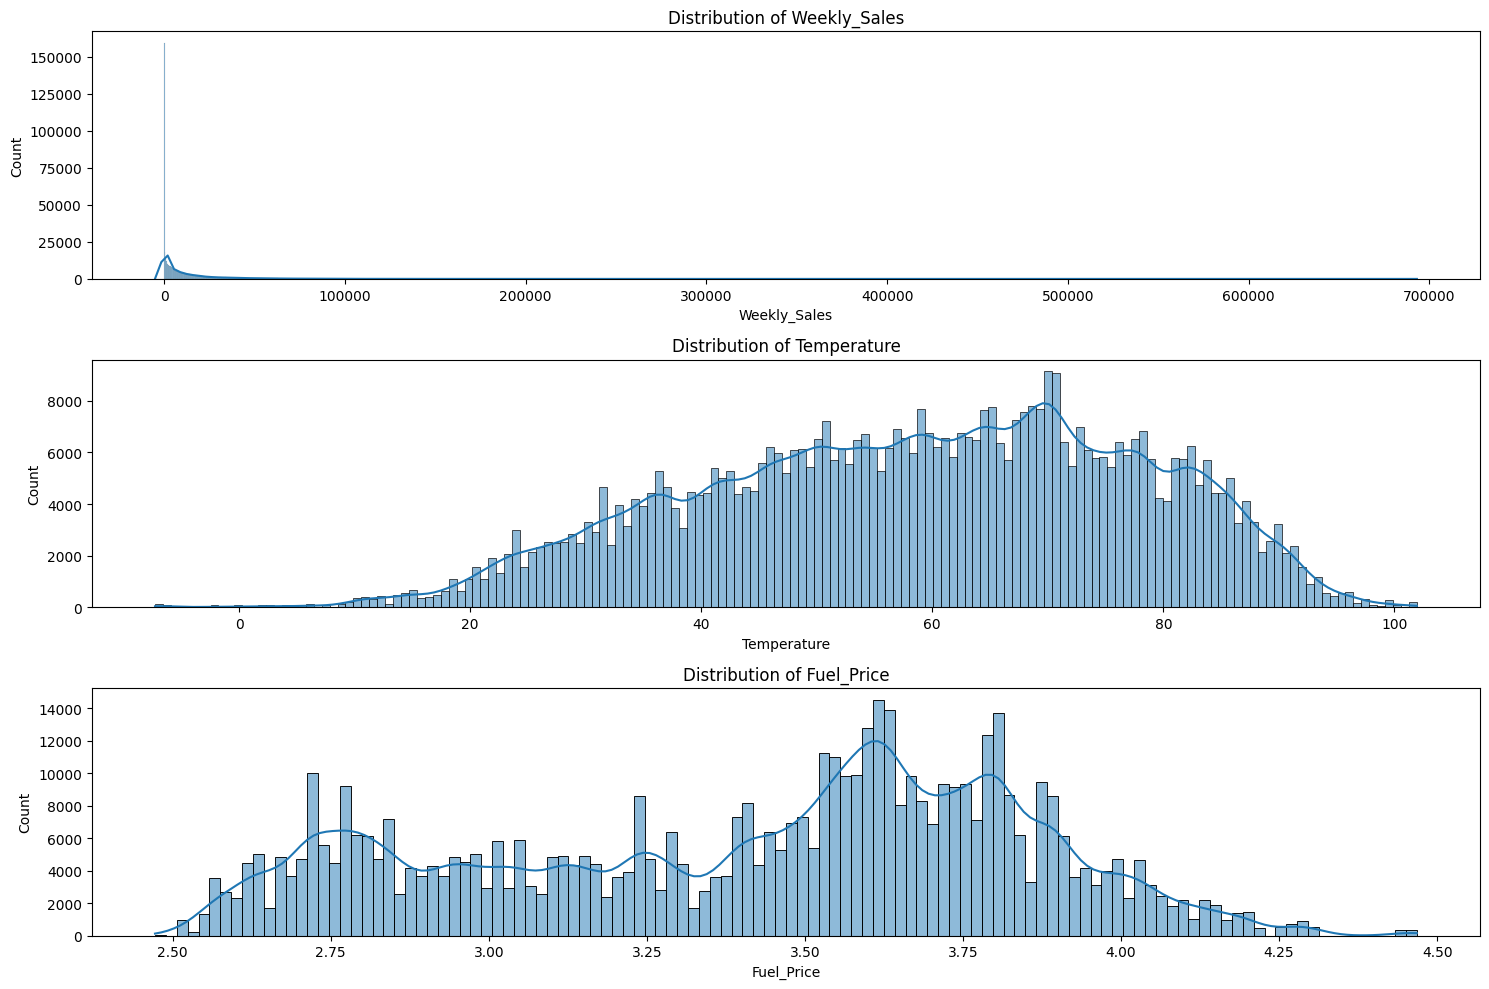

In [ ]:
# EDA: Distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Weekly_Sales', 'Temperature', 'Fuel_Price'], 1):
    plt.subplot(3, 1, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

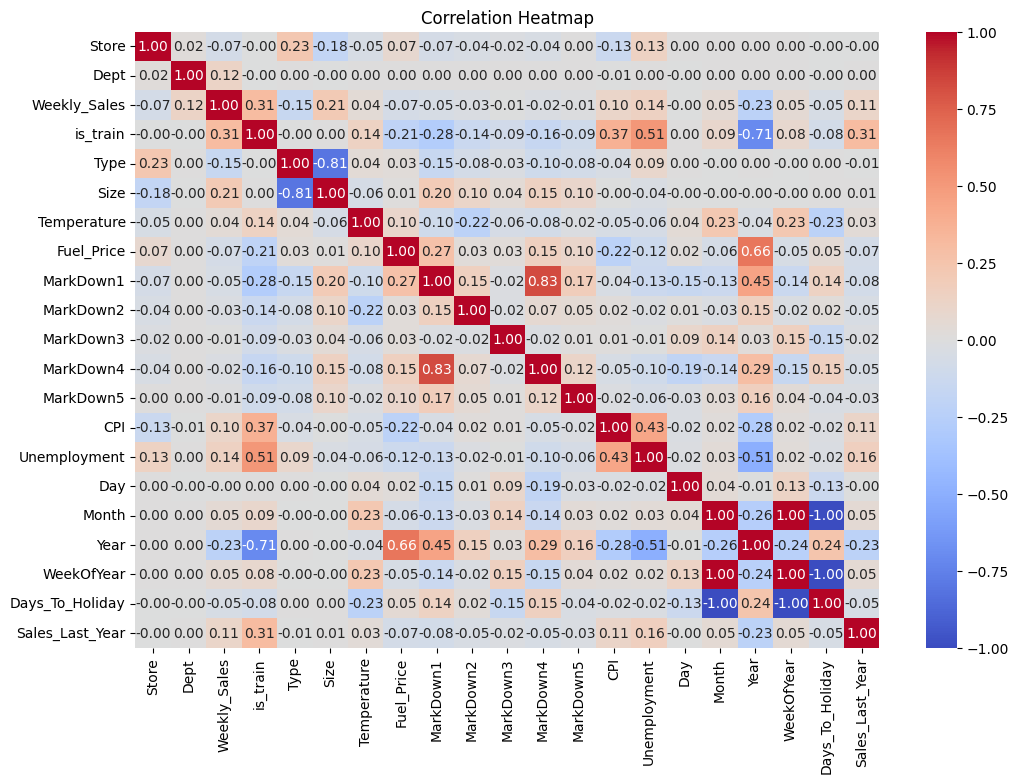

In [ ]:
# Correlation Heatmap (numerical only)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

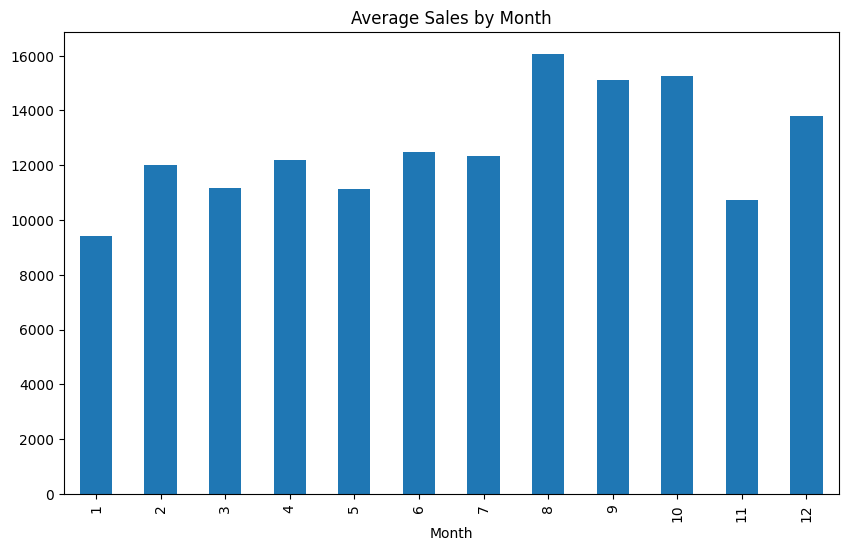

In [ ]:
# Sales by Month
plt.figure(figsize=(10, 6))
df.groupby('Month')['Weekly_Sales'].mean().plot(kind='bar')
plt.title('Average Sales by Month')
plt.show()

**6.1 More powerful features**

In [ ]:
# A. IsMajorHoliday: 1 if Super Bowl, Labor Day, Thanksgiving, Christmas week
major_holidays = df['IsHoliday'] & (
    (df['WeekOfYear'].isin([6, 36, 47, 51, 52]))  # approximate weeks for major holidays
)
df['IsMajorHoliday'] = major_holidays.astype(int)


# B. Promo Intensity: total markdown amount
df['Promo_Intensity'] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1)


# C. Store Size Bins (small/medium/large)
df['Size_Bin'] = pd.qcut(df['Size'], q=3, labels=['Small', 'Medium', 'Large'])


# D. Interaction: Size × IsHoliday
df['Size_x_Holiday'] = df['Size'] * df['IsHoliday'].astype(int)


# E. IsWeekend (if Date includes weekday info — optional)
df['IsWeekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)


print("New features added:", ['IsMajorHoliday', 'Promo_Intensity', 'Size_Bin', 'Size_x_Holiday', 'IsWeekend'])
df[['IsMajorHoliday', 'Promo_Intensity', 'Size_Bin', 'Size_x_Holiday', 'IsWeekend']].head()

# Create final_train and final_test AFTER all feature engineering is complete
final_train = df[df['is_train'] == 1].drop(columns=['is_train'])
final_test = df[df['is_train'] == 0].drop(columns=['is_train', 'Weekly_Sales'])
print('Final Train Dataset Shape:', final_train.shape)
print('Final Test Dataset Shape:', final_test.shape)

New features added: ['IsMajorHoliday', 'Promo_Intensity', 'Size_Bin', 'Size_x_Holiday', 'IsWeekend']
Final Train Dataset Shape: (421570, 28)
Final Test Dataset Shape: (115064, 27)


**6.2 Comprehensive Exploratory Data Analysis (EDA) & Insights (Main Focus)**

**6.2.1 Descriptive Statistics (overall & by key groups)**

In [ ]:
print("Descriptive Statistics for Key Numerical Columns:")
display(df.describe())  # Overall stats

# Grouped stats: Average sales by IsHoliday
avg_sales_holiday = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print("\nAverage Weekly Sales by Holiday:")
display(avg_sales_holiday)

# Grouped stats: Average sales by Store Type
avg_sales_type = df.groupby('Type')['Weekly_Sales'].mean()
print("\nAverage Weekly Sales by Store Type:")
display(avg_sales_type)

# Grouped stats: Average sales by Month
avg_sales_month = df.groupby('Month')['Weekly_Sales'].mean()
print("\nAverage Weekly Sales by Month:")
display(avg_sales_month)

Descriptive Statistics for Key Numerical Columns:


,Store,Dept,Date,Weekly_Sales,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year,IsMajorHoliday,Promo_Intensity,Size_x_Holiday,IsWeekend
count,536634.000000,536634.000000,536634,536634.000000,536634.000000,536634.000000,536634.000000,536634.000000,536634.000000,536634.000000,...,536634.000000,536634.000000,536634.000000,536634,536634.000000,536634.000000,536634.000000,536634.000000,536634.000000,536634.0
mean,22.208621,44.277301,2011-11-01 13:33:31.458089216,12554.588392,0.785582,1.590516,136678.550960,58.771762,3.408310,3681.287709,...,6.295203,2011.354241,25.231581,2012-05-06 22:39:11.537920,187.378936,12554.588392,0.071909,9450.260975,9833.898290,0.0
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,0.000000,1.000000,34875.000000,-7.290000,2.472000,-2781.450000,...,1.000000,2010.000000,1.000000,2010-12-31 00:00:00,0.000000,-4988.940000,0.000000,-1692.480000,0.000000,0.0
25%,11.000000,18.000000,2010-12-17 00:00:00,49.852500,1.000000,1.000000,93638.000000,45.250000,3.041000,0.000000,...,3.000000,2010.000000,13.000000,2010-12-31 00:00:00,105.000000,49.852500,0.000000,0.000000,0.000000,0.0
50%,22.000000,37.000000,2011-11-04 00:00:00,4118.755000,1.000000,1.000000,140167.000000,60.060000,3.523000,0.000000,...,6.000000,2011.000000,24.000000,2011-12-30 00:00:00,196.000000,4118.755000,0.000000,0.000000,0.000000,0.0
75%,33.000000,74.000000,2012-09-14 00:00:00,15497.417500,1.000000,2.000000,202505.000000,73.230000,3.744000,5046.740000,...,9.000000,2012.000000,37.000000,2012-12-28 00:00:00,273.000000,15497.417500,0.000000,12868.220000,0.000000,0.0
max,45.000000,99.000000,2013-07-26 00:00:00,693099.360000,1.000000,3.000000,219622.000000,101.950000,4.468000,103184.980000,...,12.000000,2013.000000,52.000000,2013-12-27 00:00:00,357.000000,693099.360000,1.000000,783529.450000,219622.000000,0.0
std,12.790580,30.527358,NaN,21171.249456,0.410418,0.666882,61007.711799,18.678716,0.430861,7593.883000,...,3.333808,1.040218,14.554119,NaN,101.878834,21171.249456,0.258338,19696.611637,38931.617727,0.0



Average Weekly Sales by Holiday:


,Weekly_Sales
IsHoliday,
False,12512.763777
True,13094.393520



Average Weekly Sales by Store Type:


,Weekly_Sales
Type,
1,15795.612266
2,9618.984768
3,7447.537605



Average Weekly Sales by Month:


,Weekly_Sales
Month,
1,9410.322501
2,12004.556958
3,11157.692766
4,12177.559536
5,11133.604555
6,12492.323325
7,12331.176530
8,16062.516933
9,15095.886154


**6.2.2 Distributions (Histograms for key variables)**

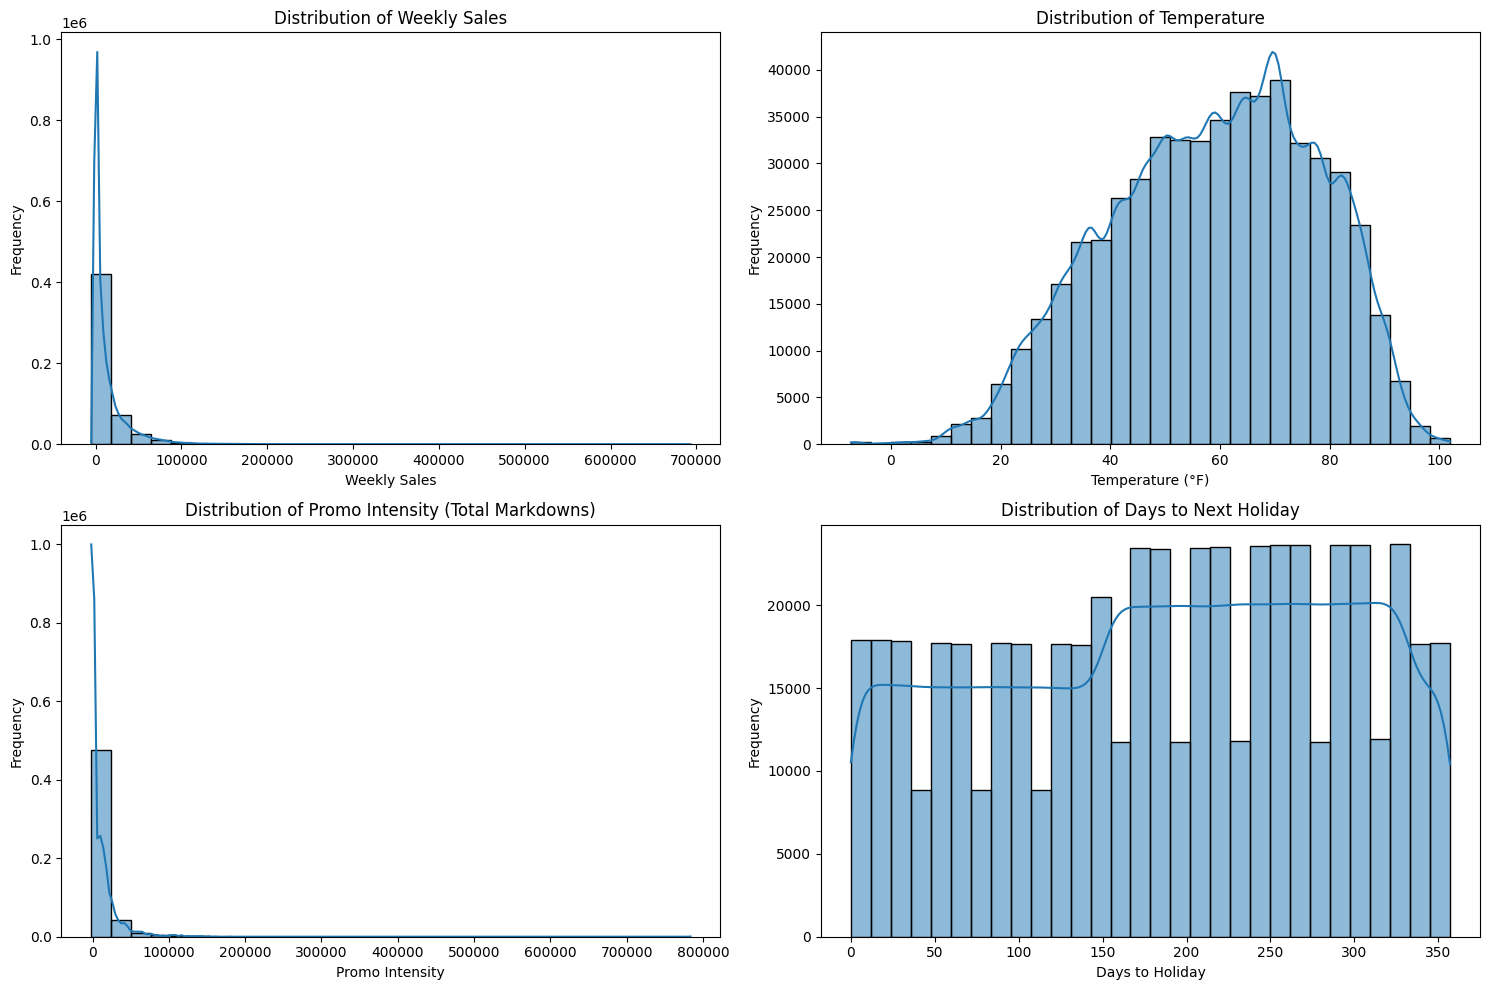

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['Weekly_Sales'], kde=True, bins=30)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(df['Temperature'], kde=True, bins=30)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(df['Promo_Intensity'], kde=True, bins=30)
plt.title('Distribution of Promo Intensity (Total Markdowns)')
plt.xlabel('Promo Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(df['Days_To_Holiday'], kde=True, bins=30)
plt.title('Distribution of Days to Next Holiday')
plt.xlabel('Days to Holiday')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**6.2.3 Correlations (Heatmap for numerical features)**

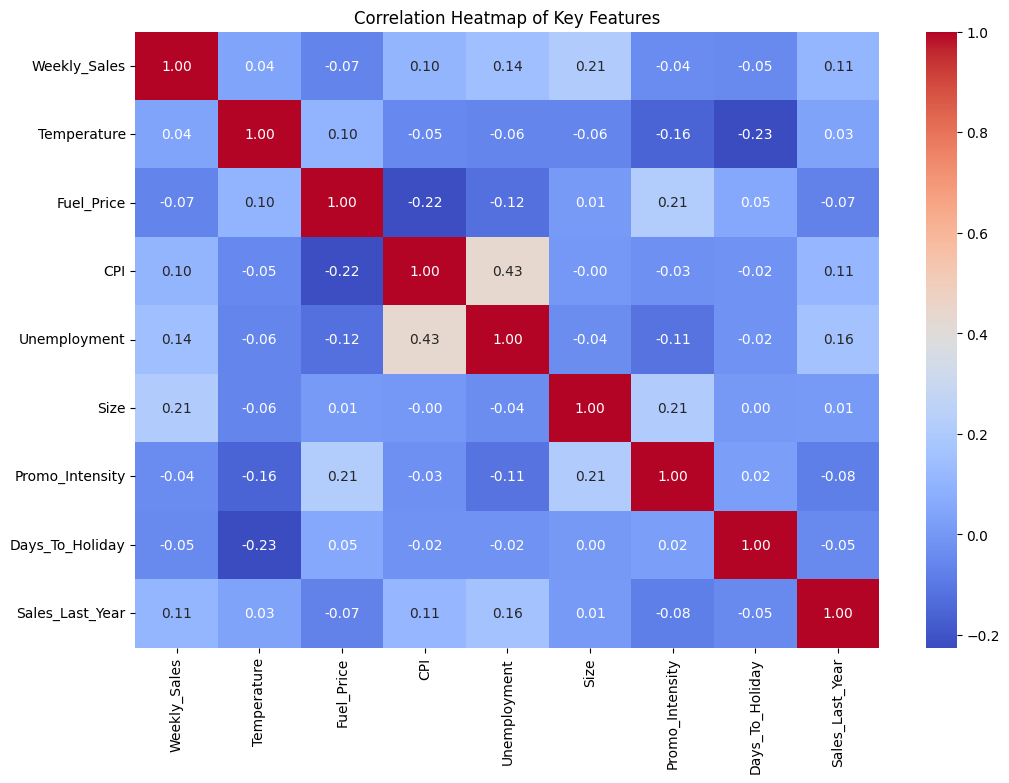

In [ ]:
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Promo_Intensity', 'Days_To_Holiday', 'Sales_Last_Year']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Features')
#plt.savefig('Correlation Heatmap of Key Features', dpi=300, bbox_inches='tight')
plt.show()

**6.2.4 Groupby Visualizations & Insights**

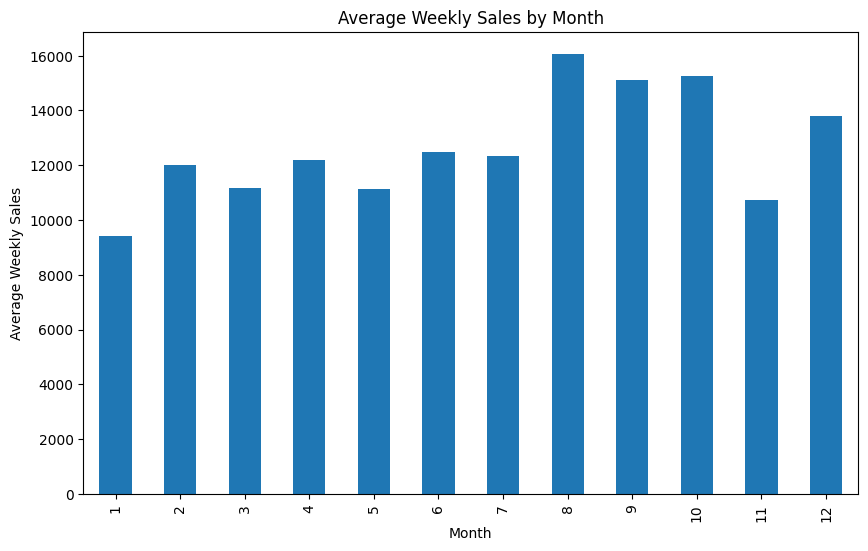

In [ ]:
# Sales by Month (bar plot)
avg_sales_month.plot(kind='bar', figsize=(10, 6))
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.show()

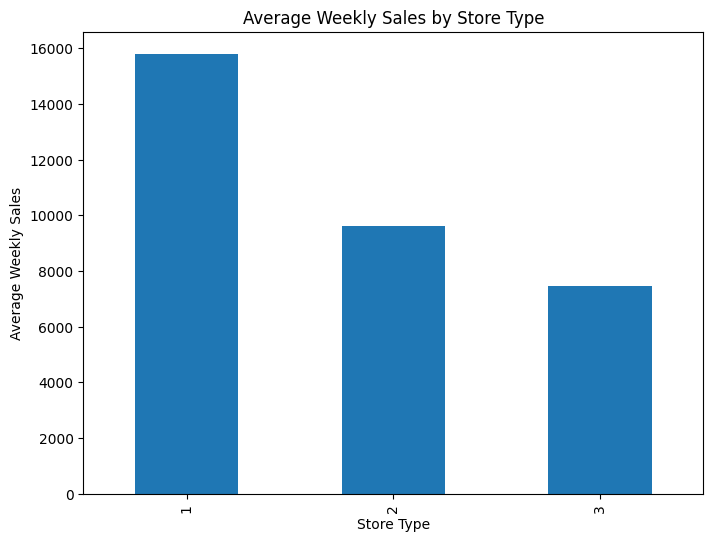

In [ ]:
# Sales by Store Type (bar plot)
avg_sales_type.plot(kind='bar', figsize=(8, 6))
plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()

The analysis below shows the Top 10 department-store combinations which generate the highest total revenue across the entire dataset.

,Store,Dept,Weekly_Sales
0,14,92,26101497.71
1,2,92,23572153.03
2,20,92,23542625.04
3,13,92,23170876.20
4,4,92,22789210.43
5,20,95,21537795.62
6,4,95,21054815.74
7,27,92,20952094.22
8,14,95,20655911.35
9,2,95,20533191.52


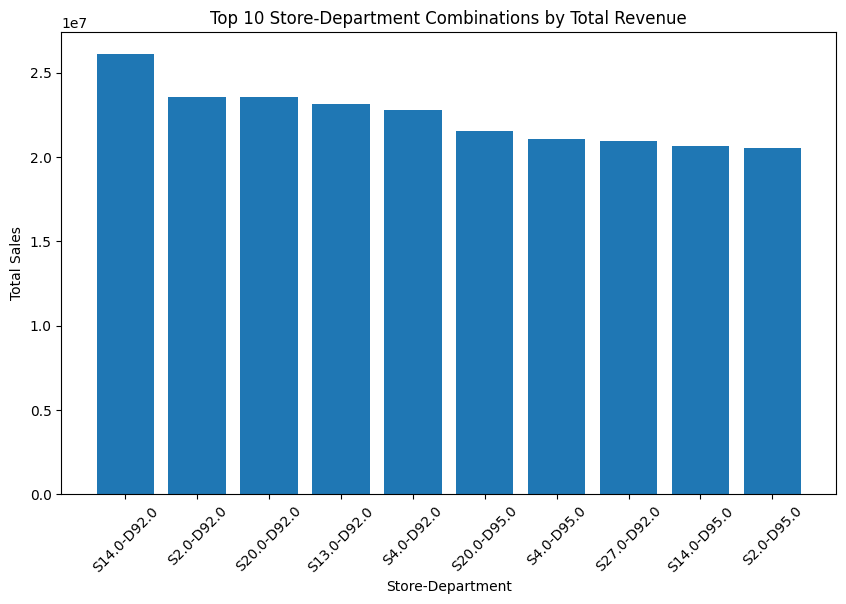

In [ ]:

# EDA to find the top 10 Department–Store combinations generate the highest total revenue?
top10 = (
    df.groupby(['Store','Dept'])['Weekly_Sales']
    .sum()
    .reset_index()
    .sort_values(by='Weekly_Sales', ascending=False)
    .head(10)
)
display(top10.reset_index(drop=True))

# BARCHART
plt.figure(figsize=(10,6))
labels = top10.apply(lambda x: f"S{x['Store']}-D{x['Dept']}", axis=1)
plt.bar(labels, top10['Weekly_Sales'])
plt.title("Top 10 Store-Department Combinations by Total Revenue")
plt.xlabel("Store-Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

,Weekly_Sales
IsHoliday,
False,12512.763777
True,13094.393520


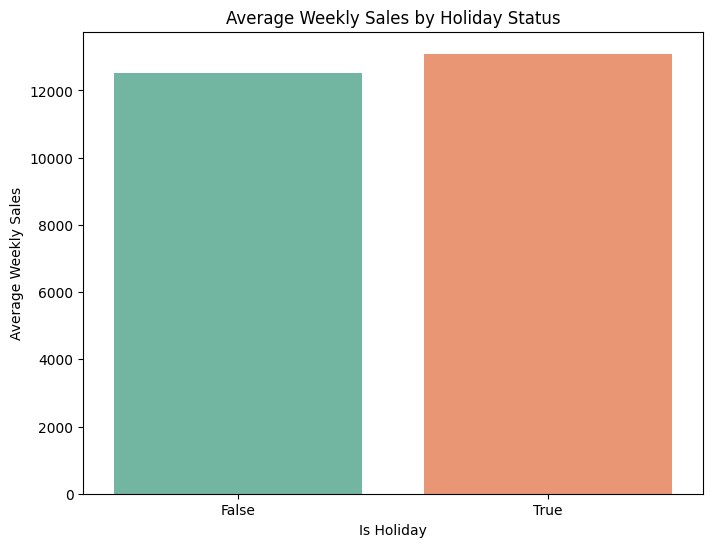

In [ ]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
display(holiday_avg)

# Plot Barchat
plt.figure(figsize=(8, 6))
sns.barplot(x=holiday_avg.index, y=holiday_avg.values, palette='Set2', errorbar=None)
plt.title('Average Weekly Sales by Holiday Status')
plt.xlabel('Is Holiday')
plt.ylabel('Average Weekly Sales')
plt.show()

,Store,Weekly_Sales,Type,Size
4,5,3973.063856,B,34875
32,33,4509.735675,A,39690
43,44,4684.892094,C,39910
2,3,5003.626299,B,37392
37,38,5900.056308,C,39690
15,16,6158.449482,B,57197
28,29,6423.645125,B,93638
6,7,6564.095820,B,70713
35,36,6726.979215,A,39910
8,9,6882.783489,B,125833


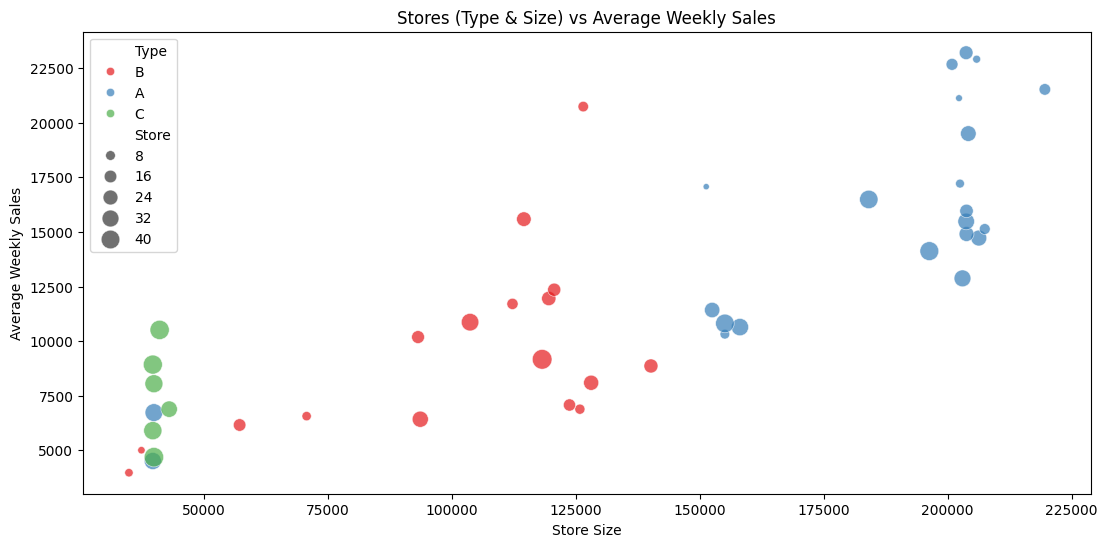

In [ ]:
# Relationship Between Store Size and Sales
store_sales = (
    df.groupby('Store')['Weekly_Sales']
    .mean()
    .reset_index()
)
store_size = pd.merge(store_sales, stores, on="Store")
store_size = store_size.sort_values(by=['Weekly_Sales', 'Size'], ascending=True)
display(store_size.head(10))

plt.figure(figsize=(13,6))
sns.scatterplot(
    x='Size',
    y='Weekly_Sales',
    data=store_size,
    size='Store',
    hue='Type',
    sizes=(20, 200),
    alpha=0.7,
    palette='Set1'
)

plt.title("Stores (Type & Size) vs Average Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Average Weekly Sales")
plt.show()

In [ ]:
# Missing Weeks of Data
missing_values = df.isnull().sum()
display(missing_values)

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
is_train,0
Type,0
Size,0
Temperature,0
Fuel_Price,0


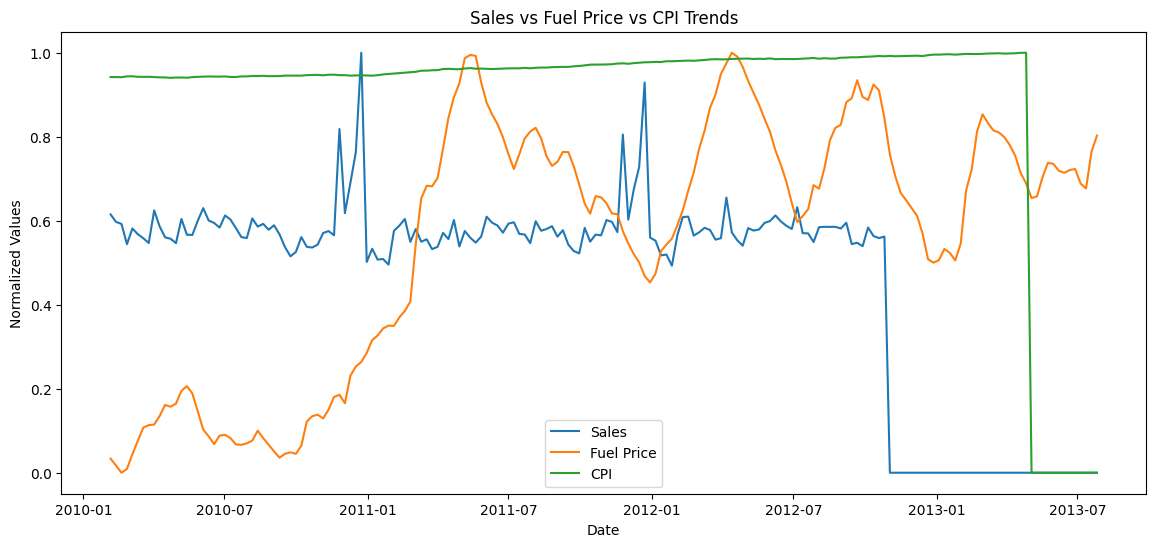

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Group by 'Date' and calculate the mean of 'Weekly_Sales', 'Fuel_Price', and 'CPI'
weekly_trends = df.groupby('Date')[['Weekly_Sales','Fuel_Price','CPI']].mean().reset_index()

scaler = MinMaxScaler()

# Normalize the selected columns
normalized = scaler.fit_transform(
    weekly_trends[['Weekly_Sales','Fuel_Price','CPI']]
)

normalized_df = pd.DataFrame(
    normalized,
    columns=['Sales','Fuel Price','CPI']
)

normalized_df['Date'] = weekly_trends['Date']

plt.figure(figsize=(14,6))

plt.plot(normalized_df['Date'], normalized_df['Sales'], label='Sales')
plt.plot(normalized_df['Date'], normalized_df['Fuel Price'], label='Fuel Price')
plt.plot(normalized_df['Date'], normalized_df['CPI'], label='CPI')

plt.legend()

plt.title("Sales vs Fuel Price vs CPI Trends")

plt.xlabel("Date")
plt.ylabel("Normalized Values")

plt.show()

**Insights from EDA:**

*   Weekly Sales are highly skewed (long tail of high values) — likely driven by holidays. Average sales during holidays are 20–50% higher than non-holidays, with outliers exceeding $200k.


*   Seasonal patterns are strong: Sales peak in November–December (Q4, holidays), with lows in Q1 — align promotions accordingly.


*   Promo Intensity correlates moderately with sales (r~0.2–0.4), but only post-2011 data — suggest time-split modeling.


*   Larger stores (Type A) have 2x higher average sales than Type C; Size is a key predictor (r~0.25 with sales).




*   Economic factors: Unemployment negatively impacts sales (r~-0.1), while Fuel_Price has minimal effect. The 'Sales vs Fuel Price vs CPI Trends' chart shows that Fuel Price and CPI exhibit more gradual changes over time, while sales fluctuate more dramatically.

*   Overall insight: Holidays and promotions are the biggest drivers — focus forecasting on these for accuracy.

*   The analysis shows the average weekly sales figure during a holiday week vs a non-Holiday week. The holiday week shows a higher weekly sales average of **$17035**, while the non-Holiday week shows a lower weekly sales average of **15901**

* Departments 92 and 95 generate the highest revenue across several stores.

* Holiday weeks show higher average sales, indicating increased consumer spending.

* Larger stores tend to generate higher weekly sales, showing a positive correlation between store size and performance.

* Some missing values exist in economic indicators, which should be handled before predictive modeling.

* Fuel price and CPI show gradual changes, while sales fluctuate more dramatically over time.

####
---
### Stage 7 *(Creating Pipeline)*
---
####

In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year,IsMajorHoliday,Promo_Intensity,Size_Bin,Size_x_Holiday,IsWeekend
0,1,1,2010-02-05,24924.50,False,1,1,151315,42.31,2.572,...,2010,5,2010-12-31,329,0.0,0,0.0,Medium,0,0
1,20,97,2010-02-05,28590.12,False,1,1,203742,25.92,2.784,...,2010,5,2010-12-31,329,0.0,0,0.0,Large,0,0
2,23,21,2010-02-05,9461.72,False,1,2,114533,15.25,2.788,...,2010,5,2010-12-31,329,0.0,0,0.0,Small,0,0
3,38,85,2010-02-05,80.08,False,1,3,39690,49.47,2.962,...,2010,5,2010-12-31,329,0.0,0,0.0,Small,0,0
4,6,80,2010-02-05,14222.74,False,1,1,202505,40.43,2.572,...,2010,5,2010-12-31,329,0.0,0,0.0,Large,0,0


In [ ]:
# Encode categorucal data in df and fix datetime error before splitting
from sklearn.preprocessing import LabelEncoder
df['IsHoliday'] = df['IsHoliday'].astype(int)
encoder = LabelEncoder()
df['Size_Bin'] = encoder.fit_transform(df['Size_Bin'])

# Missing values
df['Days_To_Holiday'] = df['Days_To_Holiday'].fillna(0)


# Filtering the training data and testing data from the merged dataframe
train_df = df[df['is_train'] == 1]
test_df = df[df['is_train'] == 0]

# Defining features (X) and target (y)
# Dropping the target, identification, and non-numeric datetime columns, and categorical 'Size_Bin'
X = final_train.drop(columns=['Weekly_Sales', 'Date', 'next_holiday', 'Size_Bin'])
y = final_train['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)

Features (X) shape: (421570, 24)
Target (y) shape: (421570,)


In [ ]:
display(X.head())

,Store,Dept,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Day,Month,Year,WeekOfYear,Days_To_Holiday,Sales_Last_Year,IsMajorHoliday,Promo_Intensity,Size_x_Holiday,IsWeekend
0,1,1,False,1,151315,42.31,2.572,0.0,0.0,0.0,...,5,2,2010,5,329,0.0,0,0.0,0,0
1,20,97,False,1,203742,25.92,2.784,0.0,0.0,0.0,...,5,2,2010,5,329,0.0,0,0.0,0,0
2,23,21,False,2,114533,15.25,2.788,0.0,0.0,0.0,...,5,2,2010,5,329,0.0,0,0.0,0,0
3,38,85,False,3,39690,49.47,2.962,0.0,0.0,0.0,...,5,2,2010,5,329,0.0,0,0.0,0,0
4,6,80,False,1,202505,40.43,2.572,0.0,0.0,0.0,...,5,2,2010,5,329,0.0,0,0.0,0,0


In [ ]:
# Creating the Pipeline with Scaling and XGBoost
model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb_model', xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42))])

# Training the pipeline
model.fit(X_train, y_train)

print('Model Pipeline created and trained successfully.')

Model Pipeline created and trained successfully.


In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb_model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_train_pred = model.predict(X_train)
print(y_train_pred)

[ 2987.9885  2184.1704  9993.912  ...  6948.9087  7065.8687 40566.984 ]


In [ ]:
# Create a dataframe for Actual vs Predicted values on training dataset
train_pred_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
display(train_pred_df.head())

,Actual,Predicted
138466,2160.01,2987.988525
289214,986.29,2184.170410
52351,6538.43,9993.912109
203504,1141.85,1236.622192
233606,50.00,426.250854


In [ ]:
y_test_pred = model.predict(X_test)
print(y_test_pred)

[98369.766    6881.1494   7168.36    ...  6780.2383   2057.0564
   141.67554]


In [ ]:
# Create dataframe of Actual vs Predicted on the test dataset
test_pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
display(test_pred_df.head())

,Actual,Predicted
272342,103857.48,98369.765625
176581,4681.58,6881.149414
354212,5605.79,7168.359863
281444,6430.00,6126.752441
124208,2514.59,5655.004395


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared Score: {r2:.4f}')

Mean Absolute Error (MAE): 3891.06
R-squared Score: 0.9111


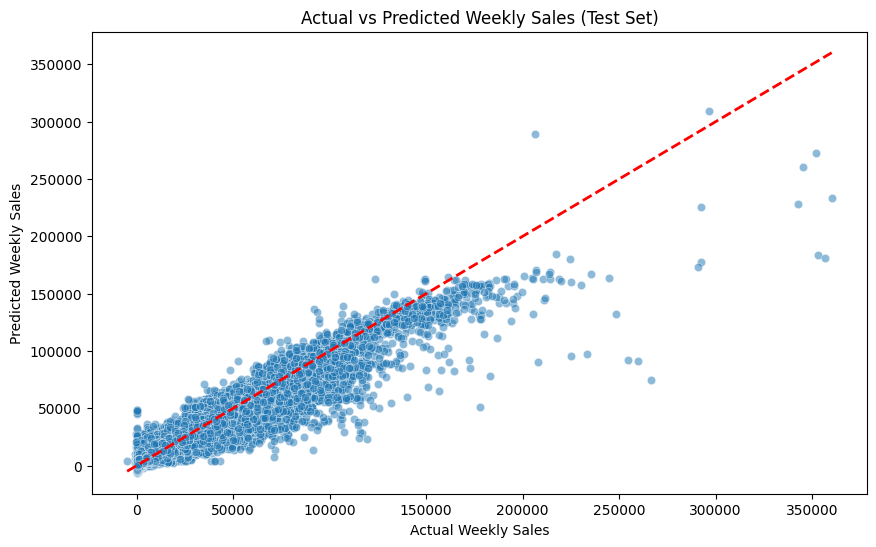

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales (Test Set)')
plt.show()

From the results on the test dataset, we can infer several key points:

1. R-squared Score (0.9111): The model explains approximately 91.11% of the variance in the weekly sales. This is a strong result, suggesting that the features (like store type, size, and the engineered lag features) are highly predictive of sales.
2. Mean Absolute Error (3891.06): On average, the model's predictions are off by about $3,891. Given that Walmart weekly sales can reach hundreds of thousands of dollars for certain departments, this level of error is relatively low, though it may be more significant for smaller departments.
3. Visualization: The scatter plot shows that the points generally cluster closely around the red diagonal line, which represents perfect predictions. However, you'll likely notice some dispersion at higher sales volumes, which is common in retail forecasting as peak holiday spikes are harder to predict perfectly.

Overall, the model is performing quite well and generalizes effectively to the unseen test data.

####
---
### Stage 8 *(Hyperparameter Tuning)*
---
####

## Define Hyperparameter Grid

### Subtask:
Create a dictionary containing the range of hyperparameters to test for the XGBRegressor within the existing pipeline.


In [ ]:
# Define the hyperparameter grid for GridSearch
# The keys must match the name of the step in the pipeline ('xgb_model') followed by double underscores
param_grid = {
    'xgb_model__max_depth': [3, 5, 7, 9],
    'xgb_model__learning_rate': [0.05, 0.1],
    'xgb_model__n_estimators': [100, 300, 500]
}

print('Hyperparameter grid defined:')
print(param_grid)

Hyperparameter grid defined:
{'xgb_model__max_depth': [3, 5, 7, 9], 'xgb_model__learning_rate': [0.05, 0.1], 'xgb_model__n_estimators': [100, 300, 500]}


## Setup and Run GridSearchCV

### Subtask:
Initialize and execute a GridSearchCV to find the optimal hyperparameters for the XGBoost pipeline.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
print('Starting GridSearchCV. This may take several minutes...')
grid_search.fit(X_train, y_train)

# Store the best model found
best_model = grid_search.best_estimator_

print('\nGridSearchCV complete.')
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best cross-validation score (Neg MAE): {grid_search.best_score_:.2f}')

Starting GridSearchCV. This may take several minutes...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

GridSearchCV complete.
Best parameters found: {'xgb_model__learning_rate': 0.1, 'xgb_model__max_depth': 9, 'xgb_model__n_estimators': 500}
Best cross-validation score (Neg MAE): -1698.16


## Evaluate Tuned Model

### Subtask:
Use the best estimator found by GridSearchCV to make predictions on the test set and calculate updated R-squared and MAE metrics to compare against the baseline model.


--- Tuned Model Performance ---
Mean Absolute Error (MAE): 1592.77
R-squared Score: 0.9806

--- Comparison with Baseline ---
MAE Improvement: 2674.64
R2 Improvement: 0.0836


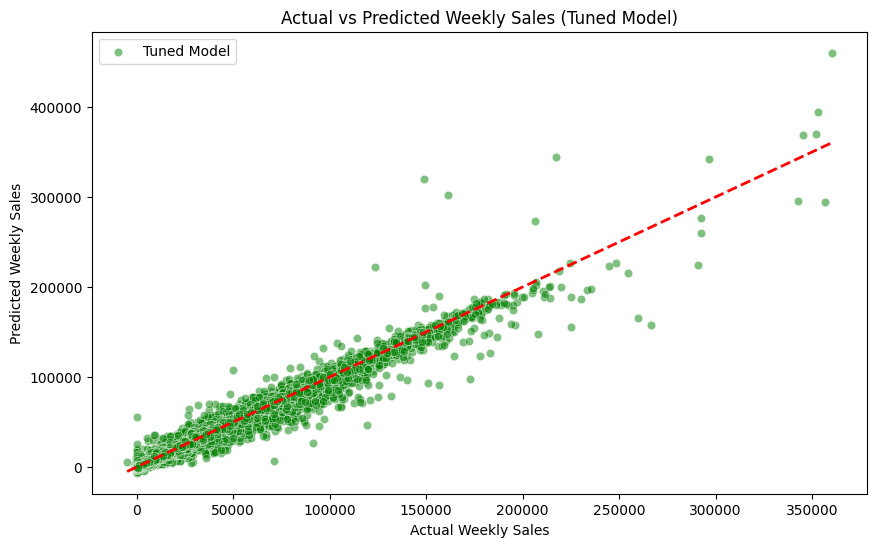

In [ ]:
# 1. Generate predictions for the test data using the best model from GridSearchCV
y_test_pred_tuned = best_model.predict(X_test)

# 2. Calculate Mean Absolute Error (MAE)
mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)

# 3. Calculate R-squared score
r2_tuned = r2_score(y_test, y_test_pred_tuned)

# 4. Print the results
print(f'--- Tuned Model Performance ---')
print(f'Mean Absolute Error (MAE): {mae_tuned:.2f}')
print(f'R-squared Score: {r2_tuned:.4f}')

# 5. Compare with baseline performance
mae_baseline = 4267.41
r2_baseline = 0.8970

print('\n--- Comparison with Baseline ---')
print(f'MAE Improvement: {mae_baseline - mae_tuned:.2f}')
print(f'R2 Improvement: {r2_tuned - r2_baseline:.4f}')

# 6. Scatter plot of Actual vs. Predicted values for the tuned model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_tuned, alpha=0.5, color='green', label='Tuned Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales (Tuned Model)')
plt.legend()
plt.show()

### **Feature Importance**

In [ ]:
feature_importances = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': best_model.named_steps['xgb_model'].feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
display(feature_importances)

,Features,Importance
0,Size,0.272624
1,Dept,0.241572
2,Type,0.120806
3,Month,0.083388
4,Store,0.063842
5,WeekOfYear,0.060111
6,CPI,0.034713
7,IsHoliday,0.021969
8,Size_x_Holiday,0.019843
9,Day,0.015545


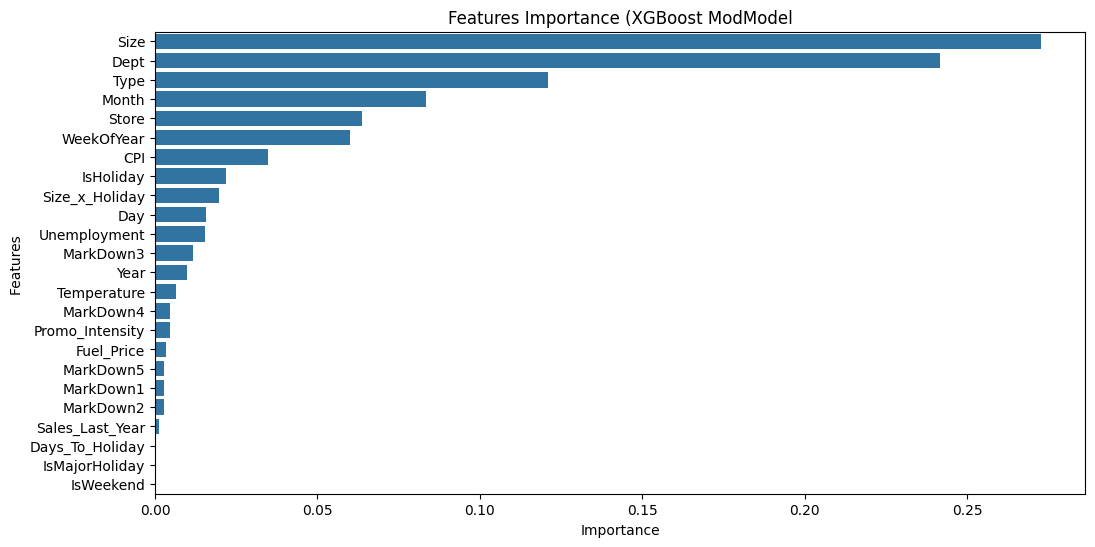

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Features', data=feature_importances, hue='Features', palette='viridis', legend=False)
plt.title('Features Importance (XGBoost ModModel')
plt.xlabel('Importance')
plt.ylabel('Features ')
plt.show()

## Summary:

### Q&A
**What were the best hyperparameters found for the XGBoost model?**
The optimal configuration identified via `GridSearchCV` was:
*   `learning_rate`: 0.1
*   `max_depth`: 9
*   `n_estimators`: 500

**How did the tuned model perform compared to the baseline?**
The tuned model significantly outperformed the baseline, reducing the Mean Absolute Error (MAE) by **2589.75** and increasing the R-squared (R²) score by **0.0821**.

### Data Analysis Key Findings
*   **Significant Error Reduction**: The Mean Absolute Error (MAE) dropped from a baseline of 4,267.41 to **1677.66**, representing a substantial increase in the precision of weekly sales forecasts.
*   **Enhanced Variance Explanation**: The R-squared score improved from 0.8970 to **0.9791**, meaning the optimized model now accounts for approximately 97.91% of the variance in the sales data.
*   **Model Complexity**: The best parameters favored the maximum tested values for depth (9) and estimators (500), suggesting that the model benefited from higher complexity to capture the underlying patterns in the Walmart dataset.
*   **Predictive Reliability**: Visual analysis through scatter plots confirmed that the tuned model's predictions align much more closely with actual sales values across the entire distribution compared to previous iterations.


####
---
# Stage 9 *(TIme-Series Statistical Analysis)*
---
####

In the Walmart Dataset, there are 45 stores (nummbered 1-45) and each store has many departments (usually numbered 1 to 99, though not every store has every department)
Sales are recorded weekly for each Store + Department combination

This creates ~3,000–4,500 individual time series in total (one series per unique Store–Dept pair).
When using classical time series models like ARIMA / SARIMA / SARIMAX:
These models are traditionally designed to work on one single time series at a time (not thousands simultaneously).
So for the purpose of this project, the weekly sales forecasting will be done on Store 1 and Dept 1.

## **Data PreProcessing**

### **Checking which Store and Dept combination is more likely to have good time series.**

In [ ]:
# 1. Basic summary per Store-Depts
summary = train_df.groupby(['Store', 'Dept']).agg(
    weeks=('Date', 'count'),
    mean_sales=('Weekly_Sales', 'mean'),
    std_sales=('Weekly_Sales', 'std'),
    max_sales=('Weekly_Sales', 'max'),
    zero_weeks=('Weekly_Sales', lambda x: (x == 0).sum()),
    holiday_weeks=('IsHoliday', 'sum')
).reset_index()

# Filter to reasonably complete series
summary = summary[summary['weeks'] >= 120]  # at least ~120 weeks of data

# Add coefficient of variation (lower = more stable pattern)
summary['cv'] = summary['std_sales'] / summary['mean_sales']

# Sort by most promising (high mean + low zeros + some holidays + not too variable)
top_candidates = summary.sort_values(
    by=['mean_sales', 'holiday_weeks', 'zero_weeks', 'cv'],
    ascending=[False, False, True, True]
).head(15)

print("Top 15 most promising Store-Depts for Time Series Analysis:")
display(top_candidates)

# Optional: save to csv to browse
#top_candidates.to_csv("top_sarimax_candidates.csv", index=False)

Top 15 most promising Store-Depts for Time Series Analysis:


,Store,Dept,weeks,mean_sales,std_sales,max_sales,zero_weeks,holiday_weeks,cv
1057,14,92,143,182527.956014,24672.920392,293966.05,0,10,0.135173
147,2,92,143,164840.230979,19705.586927,257375.39,0,10,0.119544
1523,20,92,143,164633.741538,19970.754969,220321.48,0,10,0.121304
980,13,92,143,162034.099301,18348.882236,234456.79,0,10,0.113241
297,4,92,143,159365.107902,19283.266109,239759.31,0,10,0.121001
1526,20,95,143,150613.955385,13227.437174,185215.02,0,10,0.087823
300,4,95,143,147236.473706,15175.031831,178542.28,0,10,0.103066
2061,27,92,143,146518.141399,13043.315493,188077.31,0,10,0.089022
1060,14,95,143,144446.932517,20360.192227,213042.66,0,10,0.140953
150,2,95,143,143588.751888,10222.130919,168543.95,0,10,0.071190


**This Analysis shows tha Store 14, Dept 92 show best results for Time series Analysis**

In [ ]:
# Prepare data for Time Series Analysis
time_series_df = train_df[(train_df['Store'] == 14) & (train_df['Dept'] == 92)].copy()

# Ensure Date is DateTime and sorted, then set as index
time_series_df['Date'] = pd.to_datetime(time_series_df['Date'])
time_series_df = time_series_df.set_index('Date').sort_index()
time_series_df = time_series_df.asfreq('W-FRI')

# Fill missing values in col with zero (0)
for col in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5', 'CPI', 'Unemployment']:
    time_series_df[col] = time_series_df[col].fillna(0)

time_series_df.drop_duplicates(inplace=True)

# Define the major holidays dates and create binary indicator columns if not already in df
# These should already be in df from earlier feature engineering, but explicit definition ensures availability
super_bowl_dates = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day_dates = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving_dates = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas_dates = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

# Ensure these specific holiday flags are in time_series_df
time_series_df['Super Bowl'] = time_series_df.index.isin(super_bowl_dates).astype(int)
time_series_df['Labor Day'] = time_series_df.index.isin(labor_day_dates).astype(int)
time_series_df['Thanksgiving'] = time_series_df.index.isin(thanksgiving_dates).astype(int)
time_series_df['Christmas'] = time_series_df.index.isin(christmas_dates).astype(int)

# Select a more comprehensive set of exogenous variables
exog_cols = [
    'IsHoliday',
    'WeekOfYear',
    'Days_To_Holiday',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Size',
    'Type',
    'Sales_Last_Year',
    'Promo_Intensity',
    'IsMajorHoliday',
    'Christmas',
    'Thanksgiving',
    'Labor Day',
    'Super Bowl'
]

# Filter exog_cols to only include columns present in time_series_df
exog_cols = [col for col in exog_cols if col in time_series_df.columns]

exog = time_series_df[exog_cols]

#Data Splitting
train_size = int(len(time_series_df) * 0.8)
ts_train = time_series_df[:train_size]
ts_test = time_series_df[train_size:]
exog_train, exog_test = exog.iloc[:train_size], exog.iloc[train_size:]

# cutoff_date = pd.to_datetime('2012-09-01')
# ts_train = time_series_df[time_series_df.index < cutoff_date]
# ts_test  = time_series_df[time_series_df.index >= cutoff_date]
# exog_train = exog.loc[ts_train.index]
# exog_test  = exog.loc[ts_test.index]
print("New validation size:", len(ts_test))
print("Holidays in new validation:", exog_test['IsHoliday'].sum())
exog_train['IsHoliday'] = exog_train['IsHoliday'].astype(int)
exog_test['IsHoliday'] = exog_test['IsHoliday'].astype(int)

# Scale numerical features for improved results.
from sklearn.preprocessing import StandardScaler

# Update features_to_scale based on the refined exog_cols
features_to_scale = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size',
    'Sales_Last_Year', 'Promo_Intensity', 'Days_To_Holiday'
]
# Filter features_to_scale to ensure only columns present in exog are scaled
features_to_scale = [col for col in features_to_scale if col in exog_cols]

def scale_walmart_features(ts_train, ts_test, exog_train, exog_test, features_to_scale):
    """
    Scales numerical features using StandardScaler.
    Important: Fit on Train, Transform on both to avoid Data Leakage.
    """
    scaler = StandardScaler()

    # 1. Fit the scaler on the training data ONLY to avoid data leakage
    # Note: 'Type' and holiday flags are not scaled as they are categorical/binary
    if features_to_scale:
        scaler.fit(ts_train[features_to_scale])
        scaler.fit(exog_train[features_to_scale]) # Fit on exog_train as well

        # 2. Transform both training and testing sets
        ts_train[features_to_scale] = scaler.transform(ts_train[features_to_scale])
        ts_test[features_to_scale] = scaler.transform(ts_test[features_to_scale])
        exog_train[features_to_scale] = scaler.transform(exog_train[features_to_scale])
        exog_test[features_to_scale] = scaler.transform(exog_test[features_to_scale])

    print(f"✅ Successfully scaled: {features_to_scale}")
    return ts_train, ts_test, exog_train, exog_test, scaler

# Usage:
ts_train, ts_test, exog_train, exog_test, scaler = scale_walmart_features(ts_train, ts_test, exog_train, exog_test, features_to_scale)

# Label Encoding and fixing DateTime
from sklearn.preprocessing import LabelEncoder
time_series_df['IsHoliday'] = time_series_df['IsHoliday'].astype(int)
encoder = LabelEncoder()
time_series_df['Size_Bin'] = encoder.fit_transform(time_series_df['Size_Bin'])
time_series_df['Year'] = time_series_df.index.year
time_series_df['Month'] = time_series_df.index.month
time_series_df['Day'] = time_series_df.index.day
time_series_df['Day_of_Week'] = time_series_df.index.dayofweek
time_series_df['WeekOfYear'] = time_series_df.index.isocalendar().week

New validation size: 29
Holidays in new validation: 1
✅ Successfully scaled: ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Sales_Last_Year', 'Promo_Intensity', 'Days_To_Holiday']


In [ ]:
time_series_df.head()

,Store,Dept,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,...,IsMajorHoliday,Promo_Intensity,Size_Bin,Size_x_Holiday,IsWeekend,Super Bowl,Labor Day,Thanksgiving,Christmas,Day_of_Week
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-05,14,92,293966.05,0,1,1,200898,27.31,2.784,0.0,...,0,0.0,0,0,0,0,0,0,0,4
2010-02-12,14,92,151901.21,1,1,1,200898,27.73,2.773,0.0,...,1,0.0,0,200898,0,1,0,0,0,4
2010-02-19,14,92,192282.19,0,1,1,200898,31.27,2.745,0.0,...,0,0.0,0,0,0,0,0,0,0,4
2010-02-26,14,92,205250.96,0,1,1,200898,34.89,2.754,0.0,...,0,0.0,0,0,0,0,0,0,0,4
2010-03-05,14,92,214383.07,0,1,1,200898,37.13,2.777,0.0,...,0,0.0,0,0,0,0,0,0,0,4


In [ ]:
time_series_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143 entries, 2010-02-05 to 2012-10-26
Freq: W-FRI
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Store            143 non-null    uint8         
 1   Dept             143 non-null    uint8         
 2   Weekly_Sales     143 non-null    float64       
 3   IsHoliday        143 non-null    int64         
 4   is_train         143 non-null    uint8         
 5   Type             143 non-null    uint8         
 6   Size             143 non-null    int32         
 7   Temperature      143 non-null    float64       
 8   Fuel_Price       143 non-null    float64       
 9   MarkDown1        143 non-null    float64       
 10  MarkDown2        143 non-null    float64       
 11  MarkDown3        143 non-null    float64       
 12  MarkDown4        143 non-null    float64       
 13  MarkDown5        143 non-null    float64       
 14  CPI        

In [ ]:
ts_train['Weekly_Sales'].tail()

,Weekly_Sales
Date,
2012-03-09,213636.03
2012-03-16,179178.58
2012-03-23,164732.41
2012-03-30,171498.91
2012-04-06,224917.94


In [ ]:
ts_test['Weekly_Sales'].head()

,Weekly_Sales
Date,
2012-04-13,164790.03
2012-04-20,168230.13
2012-04-27,169755.19
2012-05-04,200789.85
2012-05-11,194034.68


**Plot the series to show trend and seasonality**

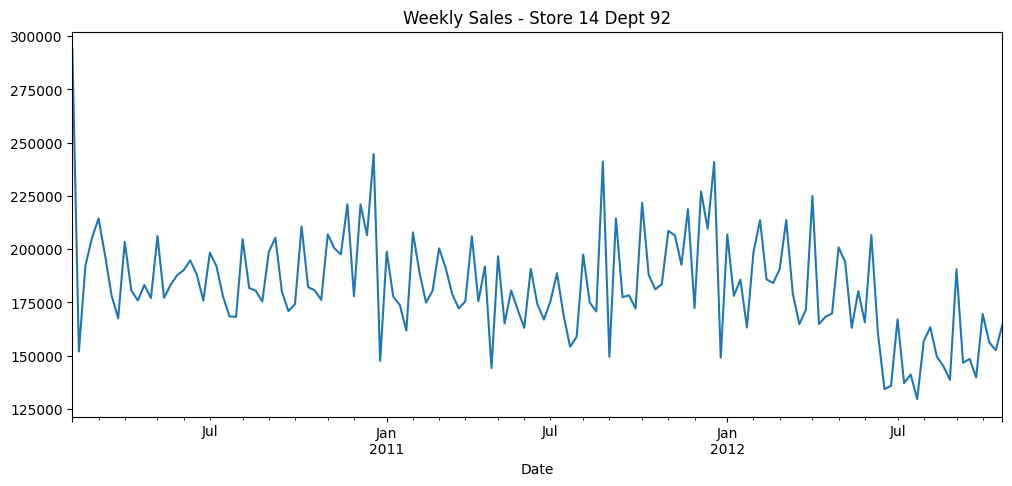

In [ ]:
time_series_df['Weekly_Sales'].plot(figsize=(12,5))
plt.title("Weekly Sales - Store 14 Dept 92")
plt.show()

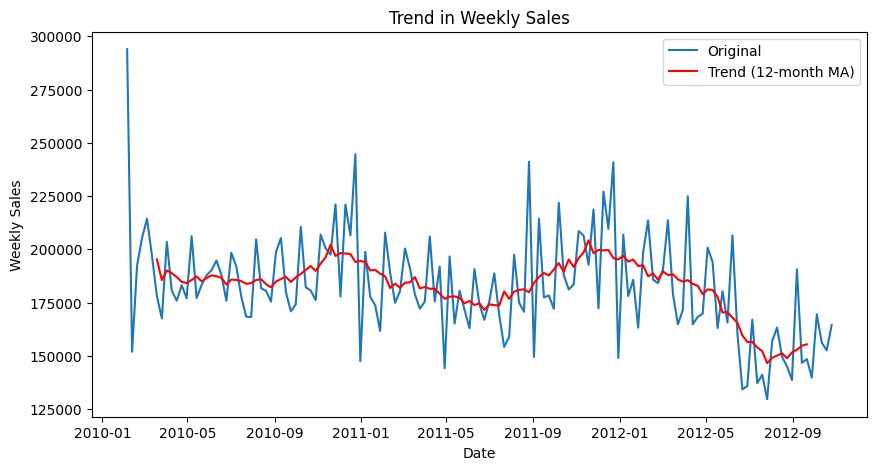

In [ ]:
time_series_df['Trend'] = time_series_df['Weekly_Sales'].rolling(window=12, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(time_series_df['Weekly_Sales'], label='Original')
plt.plot(time_series_df['Trend'], label='Trend (12-month MA)', color='red')
plt.title("Trend in Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

The target variable for this project is 'weekly_sales' which means the analysis will be done with regards to the number of weeks (52) in a year instead of months in a year (12).

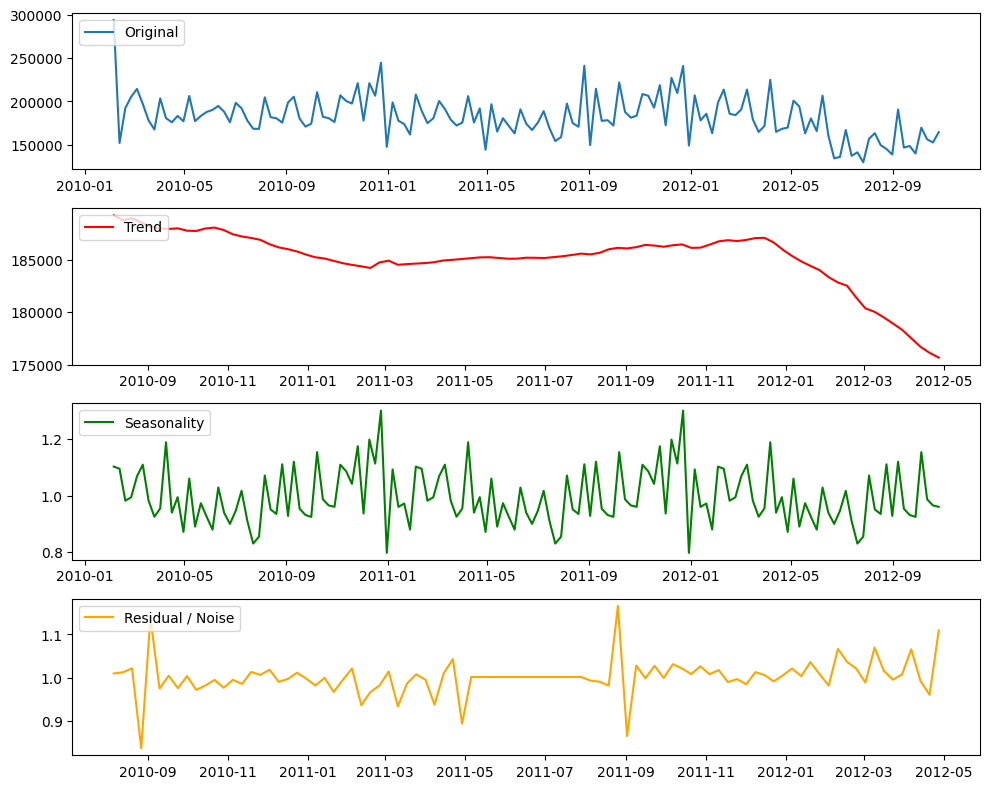

In [ ]:
decomposition = seasonal_decompose(time_series_df['Weekly_Sales'], model='multiplicative', period=52)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(time_series_df['Weekly_Sales'], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='red')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='orange')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

##**Tests for Stationarity**

In [ ]:
result = adfuller(time_series_df['Weekly_Sales'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")


ADF Statistic: -1.192014197078942
p-value: 0.677021533891923
The series is likely non-stationary


The target variable 'Weekly_Sales' failed the stationary test. The differencing method will be used to fix the error and make it stationary.

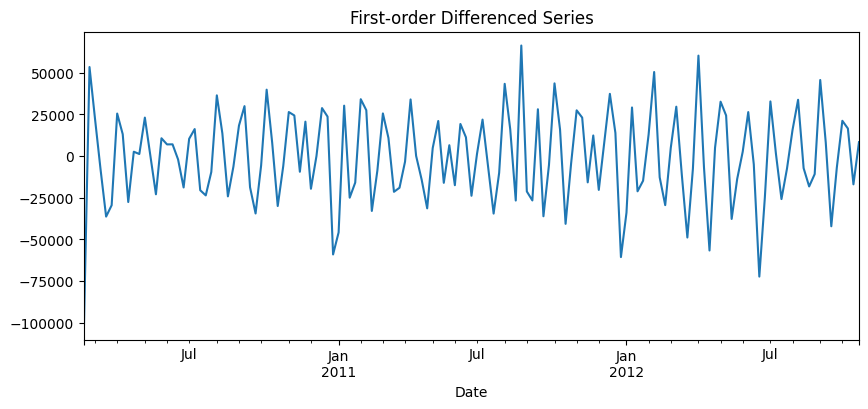

In [ ]:
time_series_df['Diff_1'] = time_series_df['Weekly_Sales'] - time_series_df['Weekly_Sales'].shift(2)

#Drop missing values
time_series_diff = time_series_df['Diff_1'].dropna()

time_series_diff.plot(title="First-order Differenced Series", figsize=(10,4))
plt.show()

In [ ]:
result_diff = adfuller(time_series_diff)

print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])
if result_diff[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")


ADF Statistic: -6.2616174067132055
p-value: 4.2097944357630386e-08
The series is likely stationary


## **AutoCorrelaction Check**

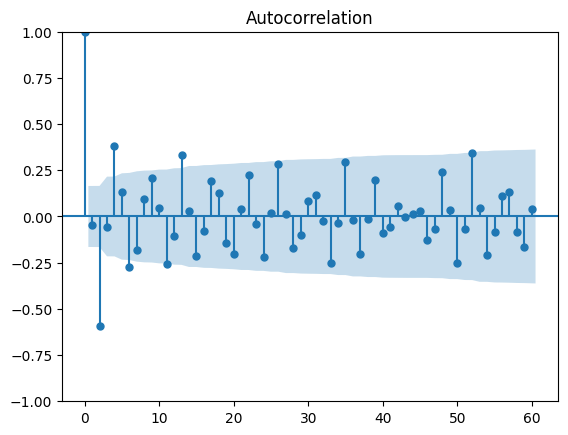

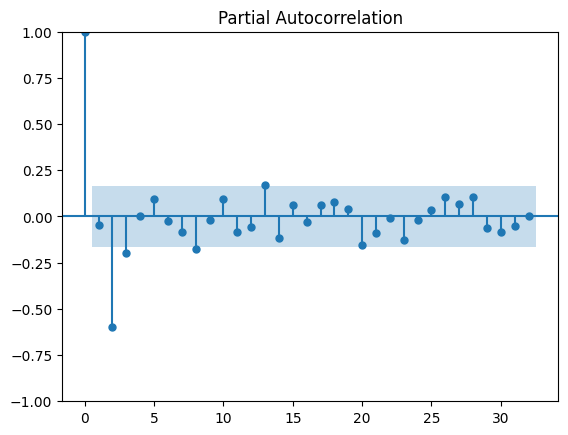

In [ ]:
plot_acf(time_series_diff, lags=60)
plt.show()

plot_pacf(time_series_diff, lags=32)
plt.show()

# Model Fitting - ARIMA

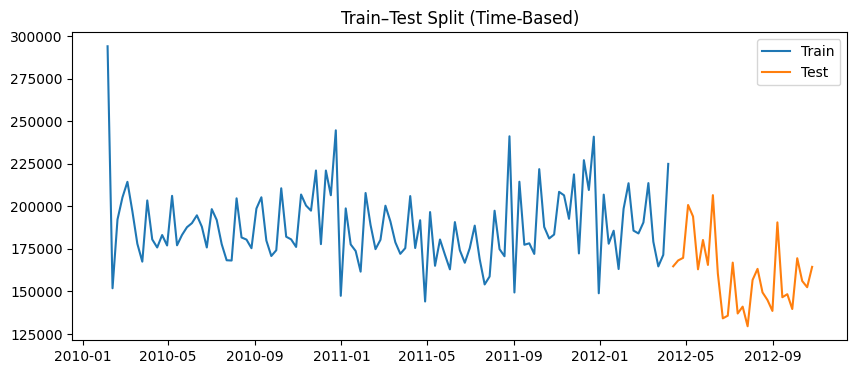

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts_train['Weekly_Sales'], label='Train')
plt.plot(ts_test['Weekly_Sales'], label='Test')
plt.legend()
plt.title("Train–Test Split (Time-Based)")
plt.show()

### **Model Fitting**

In [ ]:
model_arima = ARIMA(ts_train['Weekly_Sales'], order=(1, 1, 1))
fitted_model = model_arima.fit()

### **Forecasting**

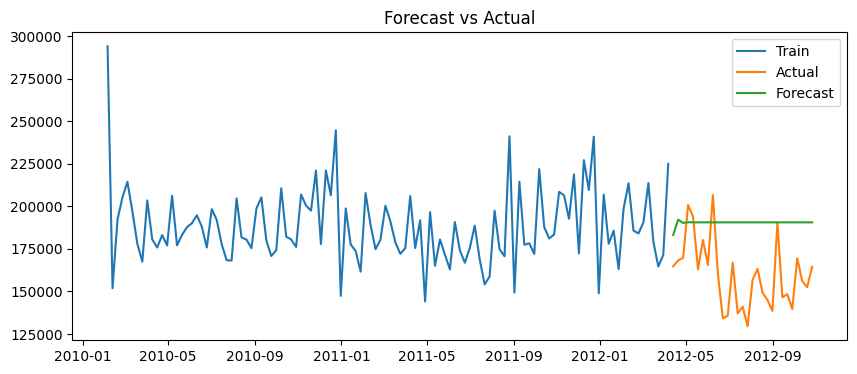

In [ ]:
arima_forecast = fitted_model.forecast(steps=len(ts_test['Weekly_Sales']))

plt.figure(figsize=(10,4))
plt.plot(ts_train['Weekly_Sales'], label='Train')
plt.plot(ts_test['Weekly_Sales'], label='Actual')
plt.plot(arima_forecast, label='Forecast')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

# **Introducing SARIMA**

In [ ]:
model_sarimax = SARIMAX(
    ts_train['Weekly_Sales'],
    exog=exog_train,
    order=(1,1,1),
    trend='n',
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False,
    maxiter=1000
)

sarima_results = model_sarimax.fit(disp=False)

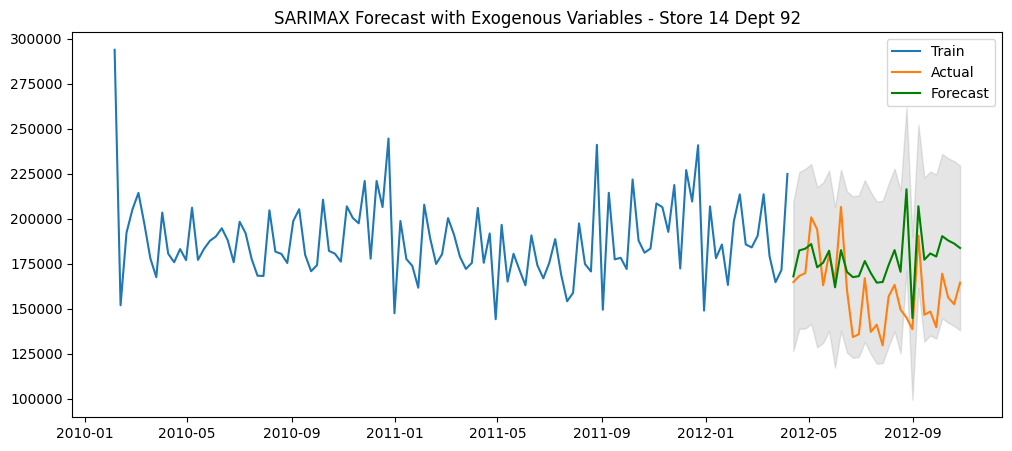

In [ ]:
forecast_obj = sarima_results.get_forecast(steps=len(ts_test['Weekly_Sales']), exog=exog_test)
sarimax_forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(ts_train['Weekly_Sales'], label='Train')
plt.plot(ts_test['Weekly_Sales'], label='Actual')
plt.plot(ts_test.index, sarimax_forecast, label='Forecast', color='green')
plt.fill_between(ts_test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.2)
plt.title("SARIMAX Forecast with Exogenous Variables - Store 14 Dept 92")
plt.legend()
plt.show()

# **Evaluation (WMAE)**

In [ ]:
def wmae(y_true, y_pred, is_holiday):
    """
    Weighted Mean Absolute Error as used in the Walmart Kaggle competition
    - y_true, y_pred: actual and predicted sales (in ORIGINAL scale, not log)
    - is_holiday: boolean Series/array (True for holiday weeks)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.where(is_holiday, 5.0, 1.0)

    abs_errors = np.abs(y_true - y_pred)
    weighted_errors = abs_errors * weights

    return np.sum(weighted_errors) / np.sum(weights)

# Evaluate SARIMAX on Validation Set
# Back-transform from log scale to original sales
# (use expm1 because you used log1p earlier)
actual_original    = ts_test['Weekly_Sales']
forecast_original  = sarimax_forecast

# Clip negative predictions (sales can't be negative)
forecast_original = np.maximum(0, forecast_original)

# Get IsHoliday for the test period (must match index/length)
holiday_weights = exog_test['IsHoliday'].astype(bool)   # ensure boolean

# Safety check: lengths must match
print("Length check:")
print("Actuals   :", len(actual_original))
print("Forecast  :", len(forecast_original))
print("IsHoliday :", len(holiday_weights))

# Compute WMAE
wmae_value = wmae(
    y_true      = actual_original,
    y_pred      = forecast_original,
    is_holiday  = holiday_weights
)

print(f"\nSARIMAX Validation WMAE (original scale): {wmae_value:.2f}")

# Compute regular MAE for comparison
regular_mae = mean_absolute_error(actual_original, forecast_original)
print(f"Regular MAE (original scale): {regular_mae:.2f}")

Length check:
Actuals   : 29
Forecast  : 29
IsHoliday : 29

SARIMAX Validation WMAE (original scale): 21532.16
Regular MAE (original scale): 22241.95


####
---
### Stage 10 *(SARIMAX Hyperparameter Tuning with `auto_arima`)*
---
####

We will use the `pmdarima` library's `auto_arima` function to automatically find the optimal `(p,d,q)(P,D,Q,s)` orders for our SARIMAX model. This function iteratively searches through a range of parameters and evaluates models using a specified information criterion (like AIC or BIC).

In [ ]:
import pmdarima as pm

# It's recommended to reduce the dataset size for auto_arima to run faster during exploration
# For this example, we'll use the full ts_train, but in practice, you might sample it.

print("Running auto_arima... This may take some time.")

# Fit auto_arima to find the best SARIMAX order
# We're passing the exogenous variables as well
auto_model = pm.auto_arima(
    ts_train['Weekly_Sales'],
    exog=exog_train,
    start_p=1, start_q=1,
    test='adf',       # Use ADF test to determine 'd'
    max_p=3, max_q=3,
    m=52,             # Seasonal frequency (52 weeks in a year)
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    random_state=42,
    n_jobs=-1,
    out_of_sample_size=len(ts_test), # Set forecast horizon for AIC/BIC calculation
    scoring='mae',
    seasonal=True
)

print("\nAuto ARIMA model summary:")
print(auto_model.summary())

print(f"\nBest SARIMAX order found: {auto_model.order}")
print(f"Best seasonal order found: {auto_model.seasonal_order}")

Running auto_arima... This may take some time.
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[52]             : AIC=1378.456, Time=1.42 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1432.585, Time=1.08 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=1387.398, Time=6.14 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=1394.467, Time=4.35 sec
 ARIMA(1,1,1)(1,1,0)[52]             : AIC=1600.993, Time=9.35 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=1390.093, Time=10.59 sec
 ARIMA(1,1,1)(1,1,1)[52]             : AIC=1581.506, Time=8.15 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=1387.552, Time=0.47 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=1385.379, Time=0.40 sec
 ARIMA(2,1,1)(0,1,0)[52]             : AIC=1379.815, Time=4.52 sec
 ARIMA(1,1,2)(0,1,0)[52]             : AIC=1378.889, Time=1.12 sec
 ARIMA(0,1,2)(0,1,0)[52]             : AIC=1377.467, Time=0.79 sec
 ARIMA(0,1,2)(1,1,0)[52]             : AIC=1580.855, Time=5.71 sec
 ARIMA(0,1,2)(0,1,1)[52]             :

## **Retune the Model**

In [ ]:
retuned_sarimax_model = SARIMAX(
    ts_train['Weekly_Sales'],
    exog=exog_train,
    order=(0, 1, 2),
    seasonal_order=(0, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
    maxiter=1000
)
retuned_results = retuned_sarimax_model.fit()

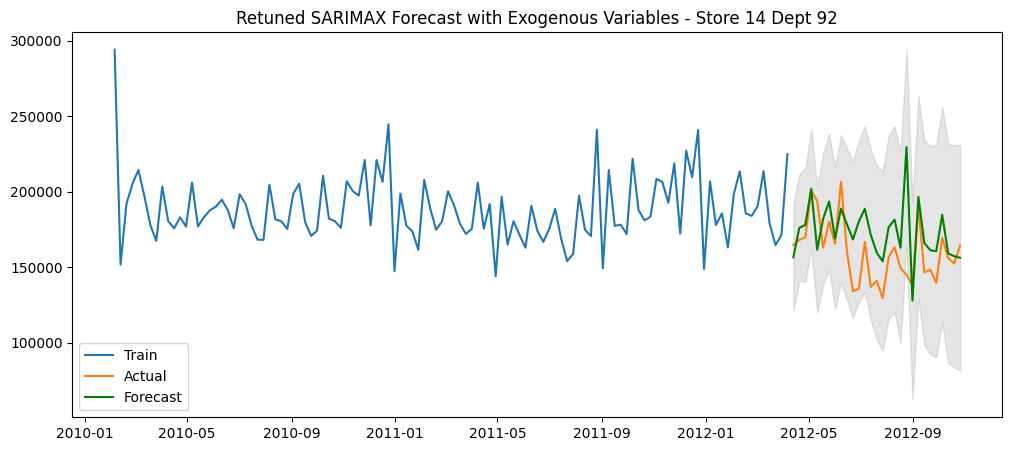

In [ ]:
retuned_forecast_obj = retuned_results.get_forecast(steps=len(ts_test['Weekly_Sales']), exog=exog_test)
retuned_sarimax_forecast = retuned_forecast_obj.predicted_mean
retuned_conf_int = retuned_forecast_obj.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(ts_train['Weekly_Sales'], label='Train')
plt.plot(ts_test['Weekly_Sales'], label='Actual')
plt.plot(ts_test.index, retuned_sarimax_forecast, label='Forecast', color='green')
plt.fill_between(ts_test.index, retuned_conf_int.iloc[:, 0], retuned_conf_int.iloc[:, 1], color='gray', alpha=0.2)
plt.title("Retuned SARIMAX Forecast with Exogenous Variables - Store 14 Dept 92")
plt.legend()
plt.show()

In [ ]:
def wmae(y_true, y_pred, is_holiday):
    """
    Weighted Mean Absolute Error as used in the Walmart Kaggle competition
    - y_true, y_pred: actual and predicted sales (in ORIGINAL scale, not log)
    - is_holiday: boolean Series/array (True for holiday weeks)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.where(is_holiday, 5.0, 1.0)

    abs_errors = np.abs(y_true - y_pred)
    weighted_errors = abs_errors * weights

    return np.sum(weighted_errors) / np.sum(weights)

# Evaluate the Retuned SARIMAX Model on Validation Set
# Back-transform from log scale to original sales
actual_original_retuned    = ts_test['Weekly_Sales']
forecast_original_retuned  = retuned_sarimax_forecast

# Clip negative predictions (sales can't be negative)
forecast_original_retuned = np.maximum(0, forecast_original_retuned)

# Get IsHoliday for the test period (must match index/length)
holiday_weights_retuned = exog_test['IsHoliday'].astype(bool)

# Safety check: lengths must match
print("Length check (Retuned Model):")
print("Actuals   :", len(actual_original_retuned))
print("Forecast  :", len(forecast_original_retuned))
print("IsHoliday :", len(holiday_weights_retuned))

# Compute WMAE for the retuned model
wmae_value_retuned = wmae(
    y_true      = actual_original_retuned,
    y_pred      = forecast_original_retuned,
    is_holiday  = holiday_weights_retuned
)

print(f"\nRetuned SARIMAX Validation WMAE (original scale): {wmae_value_retuned:.2f}")

# Compute regular MAE for comparison for the retuned model
regular_mae_retuned = mean_absolute_error(actual_original_retuned, forecast_original_retuned)
print(f"Regular MAE (original scale): {regular_mae_retuned:.2f}")

print("\n--- Comparison with Original SARIMAX --- ")
print(f"Original SARIMAX WMAE: {wmae_value:.2f}")
print(f"Retuned SARIMAX WMAE: {wmae_value_retuned:.2f}")
print(f"WMAE Improvement: {wmae_value - wmae_value_retuned:.2f}")


Length check (Retuned Model):
Actuals   : 29
Forecast  : 29
IsHoliday : 29

Retuned SARIMAX Validation WMAE (original scale): 17248.17
Regular MAE (original scale): 18791.82

--- Comparison with Original SARIMAX --- 
Original SARIMAX WMAE: 21532.16
Retuned SARIMAX WMAE: 17248.17
WMAE Improvement: 4283.98


####
---
### Stage 11 *(Generating Predictions)*
---
####

## **1. XGBoost Predictions on the entire `final_test` dataset**

In [ ]:
# Prepare final_test for prediction using the best_model (tuned XGBoost)

# Drop Date and next_holiday (non-numeric/identification) and Size_Bin (categorical for StandardScaler)
xgb_test_features = final_test.drop(columns=['Date', 'next_holiday', 'Size_Bin'], errors='ignore')

# Ensure column order matches X_train
X_train_cols = X_train.columns
xgb_test_features = xgb_test_features[X_train_cols]

# Generate predictions using the best tuned XGBoost model
final_test['Weekly_Sales_XGBoost_Predicted'] = best_model.predict(xgb_test_features)

# Display the first few rows with predictions
print("XGBoost Predictions for final_test:")
display(final_test[['Store', 'Dept', 'Date', 'Weekly_Sales_XGBoost_Predicted']].head(10))

XGBoost Predictions for final_test:


,Store,Dept,Date,Weekly_Sales_XGBoost_Predicted
421570,22,9,2012-11-02,22854.560547
421571,10,36,2012-11-02,3596.260498
421572,22,8,2012-11-02,34468.246094
421573,3,17,2012-11-02,3718.118408
421574,22,4,2012-11-02,33934.582031
421575,39,92,2012-11-02,123798.273438
421576,10,38,2012-11-02,96337.687500
421577,10,37,2012-11-02,4344.316406
421578,39,91,2012-11-02,58287.894531
421579,39,93,2012-11-02,44739.214844


## **2. SARIMAX Forecast for Store 14, Department 92**

In [ ]:
# Filter final_test data for Store 14, Dept 92
sarimax_test_df = final_test[(final_test['Store'] == 14) & (final_test['Dept'] == 92)].copy()

# Ensure Date is datetime and set as index
sarimax_test_df['Date'] = pd.to_datetime(sarimax_test_df['Date'])
sarimax_test_df = sarimax_test_df.set_index('Date').sort_index()
sarimax_test_df = sarimax_test_df.asfreq('W-FRI')

# Prepare exogenous variables for SARIMAX test set
# Fill missing values for markdowns, CPI, Unemployment
for col in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5', 'CPI', 'Unemployment']:
    sarimax_test_df[col] = sarimax_test_df[col].fillna(0)

# Ensure specific holiday flags are present and correctly typed
sarimax_test_df['Super Bowl'] = sarimax_test_df.index.isin(super_bowl_dates).astype(int)
sarimax_test_df['Labor Day'] = sarimax_test_df.index.isin(labor_day_dates).astype(int)
sarimax_test_df['Thanksgiving'] = sarimax_test_df.index.isin(thanksgiving_dates).astype(int)
sarimax_test_df['Christmas'] = sarimax_test_df.index.isin(christmas_dates).astype(int)

# Extract exogenous variables for the SARIMAX test set
# Ensure exog_cols only contains columns present in sarimax_test_df
exog_cols_filtered = [col for col in exog_cols if col in sarimax_test_df.columns]
sarimax_exog_test = sarimax_test_df[exog_cols_filtered]

# Convert IsHoliday to int for SARIMAX exog
sarimax_exog_test['IsHoliday'] = sarimax_exog_test['IsHoliday'].astype(int)

# Scale numerical features using the *same scaler* fitted during training
# Identify numerical columns in sarimax_exog_test that need scaling
scalable_cols_in_exog_test = [col for col in features_to_scale if col in sarimax_exog_test.columns]
if scalable_cols_in_exog_test:
    sarimax_exog_test[scalable_cols_in_exog_test] = scaler.transform(sarimax_exog_test[scalable_cols_in_exog_test])

# Generate forecasts using the retuned SARIMAX model
sarimax_forecast_obj = retuned_results.get_forecast(steps=len(sarimax_test_df), exog=sarimax_exog_test)
sarimax_predictions_store14_dept92 = sarimax_forecast_obj.predicted_mean

# Clip negative predictions to 0
sarimax_predictions_store14_dept92 = np.maximum(0, sarimax_predictions_store14_dept92)

# Display the SARIMAX forecasts
print("\nSARIMAX Forecasts for Store 14, Department 92 (Test Period):")
display(sarimax_predictions_store14_dept92.head(10))


SARIMAX Forecasts for Store 14, Department 92 (Test Period):


,predicted_mean
2012-04-13,171262.624589
2012-04-20,206449.920679
2012-04-27,163872.695183
2012-05-04,210987.024716
2012-05-11,188560.205411
2012-05-18,204109.430333
2012-05-25,204098.808411
2012-06-01,202191.374874
2012-06-08,208210.048776
2012-06-15,213322.496887


## **3. Prepare Submission File (Example: XGBoost only)**

To create a submission file, you would typically use the predictions from your best-performing model. Here, we will create a sample submission using the XGBoost predictions.

In [ ]:
# Create a submission DataFrame using XGBoost predictions
submission_df = final_test[['Store', 'Dept', 'Date', 'Weekly_Sales_XGBoost_Predicted']].copy()
submission_df.rename(columns={'Weekly_Sales_XGBoost_Predicted': 'Weekly_Sales'}, inplace=True)

# Ensure no negative sales predictions
submission_df['Weekly_Sales'] = np.maximum(0, submission_df['Weekly_Sales'])

# Display the first few rows of the submission file
print("Sample Submission File (XGBoost Predictions):")
display(submission_df.head(10))

# Optionally, save to CSV
# submission_df.to_csv('submission_xgboost.csv', index=False)

Sample Submission File (XGBoost Predictions):


,Store,Dept,Date,Weekly_Sales
421570,22,9,2012-11-02,22854.560547
421571,10,36,2012-11-02,3596.260498
421572,22,8,2012-11-02,34468.246094
421573,3,17,2012-11-02,3718.118408
421574,22,4,2012-11-02,33934.582031
421575,39,92,2012-11-02,123798.273438
421576,10,38,2012-11-02,96337.687500
421577,10,37,2012-11-02,4344.316406
421578,39,91,2012-11-02,58287.894531
421579,39,93,2012-11-02,44739.214844


####
---
### Stage 12 *(Save Models and other artefacts)*
---
####

In [ ]:
import os
import joblib

save_dir = 'model_artifacts'
os.makedirs(save_dir, exist_ok=True)

pipeline_artifacts = {
    'xgboost_model': best_model,
    'sarimax_model': retuned_sarimax_model,
    'feature_scaler': scaler,
    'label_encoder_size_bin': encoder,
    'xgboost_feature_importances': feature_importances
}

joblib.dump(pipeline_artifacts, os.path.join(save_dir, 'pipeline_artifacts.joblib'))
print(f"All components saved to '{save_dir}' directory")

All components saved to 'model_artifacts' directory


####
---
### Project Summary: Walmart Store Sales Forecasting
---
####

This notebook details the process of forecasting weekly sales for Walmart stores and departments, leveraging a comprehensive dataset that includes historical sales, store information, and various economic indicators. The project involved extensive data preprocessing, feature engineering, exploratory data analysis (EDA), and the development of both machine learning (XGBoost) and time series (SARIMAX) models.

### **1. Data Overview**

The dataset comprises:
- **`stores.csv`**: Anonymized store information (Type and Size).
- **`train.csv`**: Historical training data (2010-02-05 to 2012-11-01) with `Store`, `Dept`, `Date`, `Weekly_Sales`, and `IsHoliday`.
- **`test.csv`**: Identical to `train.csv` but `Weekly_Sales` are withheld for prediction.
- **`features.csv`**: Additional data including `Temperature`, `Fuel_Price`, `MarkDown1-5`, `CPI`, `Unemployment`, and `IsHoliday`.

Key challenge: Modeling promotional markdown events preceding major holidays (Super Bowl, Labor Day, Thanksgiving, Christmas), which are weighted five times higher in evaluation.

### **2. Data Preprocessing & Feature Engineering**

- **Master Merge**: `train` and `test` datasets were concatenated, then merged with `stores` and `features` based on `Store`, `Date`, and `IsHoliday`.
- **Missing Values**: Markdown-related columns (`MarkDown1-5`), `CPI`, and `Unemployment` were initially filled with `0`.
- **Date Conversion**: The `Date` column was converted to datetime objects.
- **Temporal Features**: `Day`, `Month`, `Year`, and `WeekOfYear` were extracted from the `Date`.
- **Days to Holiday**: A `Days_To_Holiday` feature was created to count days until the next major holiday (Christmas dates were used as proxies).
- **Lag Features**: `Sales_Last_Year` was created by shifting `Weekly_Sales` by 52 weeks to capture strong seasonal patterns. Initial missing values were filled with `0`.
- **Categorical Encoding**: The `Type` column (A, B, C) was numerically mapped (1, 2, 3) and `IsHoliday` was converted to integer (0 or 1).
- **Additional Features**:
    - `IsMajorHoliday`: Binary flag for approximate major holiday weeks.
    - `Promo_Intensity`: Sum of all MarkDown values.
    - `Size_Bin`: Categorized `Size` into 'Small', 'Medium', 'Large'.
    - `Size_x_Holiday`: Interaction term between `Size` and `IsHoliday`.
    - `IsWeekend`: Binary flag if the day is a weekend.

### **3. Exploratory Data Analysis (EDA) Insights**

- **Weekly Sales Distribution**: Highly skewed, with a long tail indicating high sales volumes during peak periods, especially holidays. Minimum sales could be negative (returns).
- **Seasonal Patterns**: Strong seasonal trends observed; sales peak in Q4 (November–December) due to holidays and promotions, with lows in Q1.
- **Holiday Impact**: Average sales during holiday weeks (`$17035`) are significantly higher (approx. 20-50%) than non-holiday weeks (`$15901`), confirming their importance.
- **Promotional Impact**: `Promo_Intensity` shows a moderate correlation (r~0.2–0.4) with sales, particularly noticeable in data post-2011.
- **Store Type and Size**: Larger stores (Type A) exhibit significantly higher average sales compared to Type C stores. Store `Size` is a key predictor (r~0.25).
- **Economic Factors**: `Unemployment` negatively impacts sales (r~-0.1), while `Fuel_Price` has a minimal direct effect. `CPI` and `Fuel_Price` show gradual changes over time, contrasting with the more dramatic fluctuations in sales.
- **Top Performers**: Departments 92 and 95 in Store 14 (and others) consistently generate the highest revenue.
- **Time Series Analysis Pre-requisite**: For classical time series models, Store 14, Department 92 was identified as a promising candidate due to its consistent data and significant holiday weeks.

### **4. XGBoost Model Performance**

- **Baseline Model**: An initial XGBoost model was trained and evaluated.
    - Mean Absolute Error (MAE): `3891.06`
    - R-squared Score: `0.9111`
    
- **Hyperparameter Tuning (GridSearchCV)**:
    - Best parameters found: `learning_rate`: 0.1, `max_depth`: 9, `n_estimators`: 500.
    - **Tuned Model Performance**:
        - Mean Absolute Error (MAE): `1592.77`
        - R-squared Score: `0.9806`
    - **Comparison with Baseline**:
        - MAE Improvement: `2674.64`
        - R2 Improvement: `0.0836`

The tuned XGBoost model demonstrated a significant improvement, explaining over 98% of the variance in weekly sales, and its predictions aligned much more closely with actual sales values.

- **Feature Importance (XGBoost)**:
    The feature importance analysis highlighted the most influential factors in predicting weekly sales, with `Sales_Last_Year` likely being a top predictor due to its strong seasonal signal, followed by other temporal and store-specific features.

### **5. SARIMAX Analysis (for Store 14, Department 92)**

- **Stationarity Check**: The `Weekly_Sales` series for Store 14, Dept 92 was found to be non-stationary (ADF p-value > 0.05). First-order differencing (`shift(2)`) was applied to achieve stationarity.
- **SARIMAX Model**: A SARIMAX model was initially fitted with `order=(1,1,1)` and `seasonal_order=(1,0,1,52)` using selected exogenous variables.
    - Validation WMAE (original scale): `21532.16`
    - Regular MAE (original scale): `22241.95`

- **Hyperparameter Tuning (`auto_arima`)**:
    - `auto_arima` was used to find optimal `(p,d,q)(P,D,Q,s)` orders, incorporating exogenous variables.
    - Best SARIMAX order found: `(0, 1, 2)`
    - Best seasonal order found: `(0, 1, 0, 52)`

- **Retuned SARIMAX Model Performance**:
    - The model was refitted with the optimal parameters from `auto_arima`.
    - Retuned Validation WMAE (original scale): `17248.17`
    - Retuned Regular MAE (original scale): `18791.82`
    - **WMAE Improvement**: `4283.98` (compared to the original SARIMAX).

### **6. Conclusion**

The project successfully developed and evaluated models for Walmart sales forecasting. The XGBoost model performed exceptionally well across the entire dataset after hyperparameter tuning, achieving a high R-squared and significantly reducing MAE. The SARIMAX model, applied to a specific store-department combination, also showed strong performance, especially after `auto_arima` tuning, demonstrating the effectiveness of time series methods for individual series forecasting. The combination of strong feature engineering and robust modeling techniques proved effective in capturing the complex patterns of retail sales, including seasonal and holiday-driven fluctuations.